# Bloc 1 : High-Dimensional Linear Modeling & Feature Engineering

## Modélisation linéaire en grande dimension et ingénierie des variables

## 1. Chargement des données

In [268]:
import pandas as pd

df = pd.read_csv("eco2mix-national-cons-def.csv", sep=";")

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\756792411.py:3: DtypeWarning: Columns (0: Ech. comm. Allemagne-Belgique (MW), 1: Gaz - Cogénération (MW)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("eco2mix-national-cons-def.csv", sep=";")


## 2. Exploration rapide du jeu de données

In [269]:
df.head()
df.info(36)

<class 'pandas.DataFrame'>
RangeIndex: 508320 entries, 0 to 508319
Data columns (total 37 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Périmètre                                  508320 non-null  str    
 1   Nature                                     508320 non-null  str    
 2   Date                                       508320 non-null  str    
 3   Heure                                      508320 non-null  str    
 4   Date et Heure                              508320 non-null  str    
 5   Consommation (MW)                          254160 non-null  float64
 6   Prévision J-1 (MW)                         508320 non-null  int64  
 7   Prévision J (MW)                           508320 non-null  int64  
 8   Fioul (MW)                                 254160 non-null  float64
 9   Charbon (MW)                               254160 non-null  float64
 10  Gaz (MW)           

## 3. Nettoyage des données

### 3.1 Sélection des colonnes utiles

In [270]:
print(df["Périmètre"].value_counts(dropna=False))

print(df["Nature"].value_counts(dropna=False))

Périmètre
France    508320
Name: count, dtype: int64
Nature
Données définitives    455904
Données consolidées     52416
Name: count, dtype: int64


In [271]:
print(
    df.groupby("Nature")["Consommation (MW)"]
      .agg(["count", "size"])
)

                      count    size
Nature                             
Données consolidées   26208   52416
Données définitives  227952  455904


In [272]:
print(df["Date et Heure"].duplicated().sum())

60


In [273]:
df[
    df["Date et Heure"].duplicated(keep=False)
][
    ["Nature", "Date et Heure", "Consommation (MW)"]
].head(20)

,Nature,Date et Heure,Consommation (MW)
8072,Données définitives,2012-03-25T01:00:00+00:00,46435.0
8073,Données définitives,2012-03-25T01:00:00+00:00,46435.0
8074,Données définitives,2012-03-25T01:15:00+00:00,NaN
8075,Données définitives,2012-03-25T01:15:00+00:00,NaN
8076,Données définitives,2012-03-25T01:30:00+00:00,46383.0
8077,Données définitives,2012-03-25T01:30:00+00:00,47196.0
8078,Données définitives,2012-03-25T01:45:00+00:00,NaN
8079,Données définitives,2012-03-25T01:45:00+00:00,NaN
43688,Données définitives,2013-03-31T01:00:00+00:00,62421.0
43689,Données définitives,2013-03-31T01:00:00+00:00,62421.0


In [274]:
df_energy = df[
    ["Date et Heure", "Consommation (MW)", "Nature"]
].dropna(subset=["Consommation (MW)"]).copy()

### 3.2 Conversion de la date

In [275]:
df_energy["Date et Heure"] = pd.to_datetime(
    df_energy["Date et Heure"],
    utc=True
)

In [276]:
df_energy.duplicated(
    subset=["Date et Heure"]
).sum()

np.int64(30)

In [277]:
df_energy[
    df_energy.duplicated(
        subset=["Date et Heure"],
        keep=False
    )
].head(20)

,Date et Heure,Consommation (MW),Nature
8072,2012-03-25 01:00:00+00:00,46435.0,Données définitives
8073,2012-03-25 01:00:00+00:00,46435.0,Données définitives
8076,2012-03-25 01:30:00+00:00,46383.0,Données définitives
8077,2012-03-25 01:30:00+00:00,47196.0,Données définitives
43688,2013-03-31 01:00:00+00:00,62421.0,Données définitives
43689,2013-03-31 01:00:00+00:00,62421.0,Données définitives
43692,2013-03-31 01:30:00+00:00,62765.0,Données définitives
43693,2013-03-31 01:30:00+00:00,62694.0,Données définitives
78632,2014-03-30 01:00:00+00:00,48138.0,Données définitives
78633,2014-03-30 01:00:00+00:00,48138.0,Données définitives


### 3.3 Gestion des doublons

In [278]:
df_energy = (
    df_energy
    .groupby("Date et Heure", as_index=False)
    ["Consommation (MW)"]
    .mean()
)

In [279]:
df_energy = df_energy.set_index("Date et Heure")

In [280]:
print(df_energy.index.to_series().diff().value_counts().head())

Date et Heure
0 days 00:30:00    254115
0 days 01:30:00        14
Name: count, dtype: int64


In [281]:
print(df_energy.shape)
print(df_energy.head())
print(df_energy.index.to_series().diff().value_counts().head())

(254130, 1)
                           Consommation (MW)
Date et Heure                               
2011-12-31 23:00:00+00:00            58315.0
2011-12-31 23:30:00+00:00            58315.0
2012-01-01 00:00:00+00:00            56231.0
2012-01-01 00:30:00+00:00            56075.0
2012-01-01 01:00:00+00:00            55532.0
Date et Heure
0 days 00:30:00    254115
0 days 01:30:00        14
Name: count, dtype: int64


In [282]:
diffs = df_energy.index.to_series().diff()

gaps = diffs[diffs > pd.Timedelta("30min")]

print(gaps)

Date et Heure
2012-10-28 01:00:00+00:00   0 days 01:30:00
2013-10-27 01:00:00+00:00   0 days 01:30:00
2014-10-26 01:00:00+00:00   0 days 01:30:00
2015-10-25 01:00:00+00:00   0 days 01:30:00
2016-10-30 01:00:00+00:00   0 days 01:30:00
2017-10-29 01:00:00+00:00   0 days 01:30:00
2018-10-28 01:00:00+00:00   0 days 01:30:00
2019-10-27 01:00:00+00:00   0 days 01:30:00
2020-10-25 01:00:00+00:00   0 days 01:30:00
2021-10-31 01:00:00+00:00   0 days 01:30:00
2022-10-30 01:00:00+00:00   0 days 01:30:00
2023-10-29 01:00:00+00:00   0 days 01:30:00
2024-10-27 01:00:00+00:00   0 days 01:30:00
2025-10-26 01:00:00+00:00   0 days 01:30:00
Name: Date et Heure, dtype: timedelta64[us]


In [283]:
for t in gaps.index[:5]:
    print(df_energy.loc[t - pd.Timedelta("2h"): t + pd.Timedelta("2h")])

                           Consommation (MW)
Date et Heure                               
2012-10-27 23:00:00+00:00            54322.0
2012-10-27 23:30:00+00:00            53840.0
2012-10-28 01:00:00+00:00            53170.0
2012-10-28 01:30:00+00:00            48961.0
2012-10-28 02:00:00+00:00            47836.0
2012-10-28 02:30:00+00:00            47635.0
2012-10-28 03:00:00+00:00            47430.0
                           Consommation (MW)
Date et Heure                               
2013-10-26 23:00:00+00:00            41803.0
2013-10-26 23:30:00+00:00            41053.0
2013-10-27 01:00:00+00:00            40350.0
2013-10-27 01:30:00+00:00            39385.0
2013-10-27 02:00:00+00:00            37368.0
2013-10-27 02:30:00+00:00            34585.0
2013-10-27 03:00:00+00:00            34019.0
                           Consommation (MW)
Date et Heure                               
2014-10-25 23:00:00+00:00            44503.0
2014-10-25 23:30:00+00:00            43983.0
2014-10-26

### 3.4 Régularisation de la fréquence temporelle

In [284]:
df_energy = df_energy.asfreq("30min")

In [285]:
print(df_energy.isna().sum())

Consommation (MW)    28
dtype: int64


### 3.5 Gestion des valeurs manquantes

In [286]:
df_energy["Consommation (MW)"] = (
    df_energy["Consommation (MW)"]
    .interpolate(method="time")
)

In [287]:
print(df_energy.isna().sum())

print(
    df_energy.index.to_series()
    .diff()
    .value_counts()
    .head()
)

Consommation (MW)    0
dtype: int64
Date et Heure
0 days 00:30:00    254157
Name: count, dtype: int64


## 4. Création des variables temporelles

In [288]:
df_model = df_energy.copy()

# Lags
df_model["lag_1"] = df_model["Consommation (MW)"].shift(1)
df_model["lag_48"] = df_model["Consommation (MW)"].shift(48)
df_model["lag_336"] = df_model["Consommation (MW)"].shift(336)

# Moyennes mobiles, uniquement avec le passé
df_model["rolling_48"] = (
    df_model["Consommation (MW)"]
    .shift(1)
    .rolling(48)
    .mean()
)

df_model["rolling_336"] = (
    df_model["Consommation (MW)"]
    .shift(1)
    .rolling(336)
    .mean()
)

# Variables calendaires
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek
df_model["month"] = df_model.index.month

In [289]:
df_model = df_model.dropna()

In [290]:
print(df_model.shape)

print(
    df_model[
        [
            "Consommation (MW)",
            "lag_1",
            "lag_48",
            "lag_336",
            "rolling_48",
            "rolling_336",
            "hour",
            "dayofweek",
            "month"
        ]
    ].head()
)

(253822, 9)
                           Consommation (MW)    lag_1   lag_48  lag_336  \
Date et Heure                                                             
2012-01-07 23:00:00+00:00            63684.0  63896.0  68419.0  58315.0   
2012-01-07 23:30:00+00:00            62093.0  63684.0  66338.0  58315.0   
2012-01-08 00:00:00+00:00            59359.0  62093.0  63504.0  56231.0   
2012-01-08 00:30:00+00:00            59015.0  59359.0  62899.0  56075.0   
2012-01-08 01:00:00+00:00            58290.0  59015.0  62078.0  55532.0   

                             rolling_48   rolling_336  hour  dayofweek  month  
Date et Heure                                                                  
2012-01-07 23:00:00+00:00  63160.562500  64191.958333    23          5      1  
2012-01-07 23:30:00+00:00  63061.916667  64207.937500    23          5      1  
2012-01-08 00:00:00+00:00  62973.479167  64219.181548     0          6      1  
2012-01-08 00:30:00+00:00  62887.125000  64228.491071     0   

## 5. Préparation du jeu de données pour la modélisation

### 5.1 Définition de la cible

In [291]:
target = "Consommation (MW)"

### 5.2 Sélection des features

In [292]:
features = [
    "hour",
    "dayofweek",
    "month",
    "lag_1",
    "lag_48",
    "lag_336",
    "rolling_48",
    "rolling_336"
]

### 5.3 Suppression des valeurs manquantes créées par les lags

In [293]:
df_model = df_model.dropna()

In [294]:
X = df_model[features]
y = df_model[target]

In [295]:
print(X.shape)
print(y.shape)

print(X.isna().sum())

(253822, 8)
(253822,)
hour           0
dayofweek      0
month          0
lag_1          0
lag_48         0
lag_336        0
rolling_48     0
rolling_336    0
dtype: int64


## 6. Séparation temporelle Train / Test

In [296]:
print(df_model.index.min())
print(df_model.index.max())

2012-01-07 23:00:00+00:00
2026-06-30 21:30:00+00:00


In [297]:
X_train = X.loc[X.index < "2025-01-01"]
y_train = y.loc[y.index < "2025-01-01"]

X_val = X.loc[
    (X.index >= "2025-01-01") &
    (X.index < "2026-01-01")
]
y_val = y.loc[
    (y.index >= "2025-01-01") &
    (y.index < "2026-01-01")
]

X_test = X.loc[X.index >= "2026-01-01"]
y_test = y.loc[y.index >= "2026-01-01"]

In [298]:
print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

print("\nTrain :")
print(X_train.index.min(), "->", X_train.index.max())

print("\nValidation :")
print(X_val.index.min(), "->", X_val.index.max())

print("\nTest :")
print(X_test.index.min(), "->", X_test.index.max())

Train : (227618, 8)
Validation : (17520, 8)
Test : (8684, 8)

Train :
2012-01-07 23:00:00+00:00 -> 2024-12-31 23:30:00+00:00

Validation :
2025-01-01 00:00:00+00:00 -> 2025-12-31 23:30:00+00:00

Test :
2026-01-01 00:00:00+00:00 -> 2026-06-30 21:30:00+00:00


## 7. Modèle de référence — OLS

### 7.1 Entraînement du modèle

In [299]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression()

ols.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -36.16,-129.34, 6.29,..., 0.04, -0.01, -0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['hour','dayofweek','month',...,'lag_336','rolling_48','rolling_336']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,807.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [300]:
y_val_pred_ols = ols.predict(X_val)

### 7.2 Évaluation sur l'année 2025

In [301]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_ols = mean_absolute_error(y_val, y_val_pred_ols)

rmse_ols = np.sqrt(
    mean_squared_error(y_val, y_val_pred_ols)
)

print("OLS MAE :", mae_ols)
print("OLS RMSE :", rmse_ols)

OLS MAE : 800.8130656458969
OLS RMSE : 1010.3953289434594


In [302]:
coef_ols = pd.Series(
    ols.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print(coef_ols)

dayofweek     -129.336585
hour           -36.162379
month            6.294770
lag_1            0.878911
lag_48           0.107365
lag_336          0.044908
rolling_336     -0.020473
rolling_48      -0.011563
dtype: float64


In [303]:
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["dow_sin"] = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

In [304]:
features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "lag_1",
    "lag_48",
    "lag_336",
    "rolling_48",
    "rolling_336"
]

In [305]:
X = df_model[features]
y = df_model["Consommation (MW)"]

In [306]:
X_train = X.loc[X.index < "2025-01-01"]

X_val = X.loc[
    (X.index >= "2025-01-01") &
    (X.index < "2026-01-01")
]

X_test = X.loc[X.index >= "2026-01-01"]

In [307]:
ols.fit(X_train, y_train)

y_val_pred_ols = ols.predict(X_val)

In [308]:
coef_ols = pd.Series(
    ols.coef_,
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print(coef_ols)

hour_sin       506.286920
dow_cos        359.300383
hour_cos       -92.586283
month_cos       64.865354
month_sin      -35.149608
dow_sin        -25.044552
lag_1            0.871235
rolling_336     -0.082692
lag_48           0.078174
lag_336          0.071363
rolling_48       0.059699
dtype: float64


In [309]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_train_pred_ols = ols.predict(X_train)
y_val_pred_ols = ols.predict(X_val)

rmse_train_ols = np.sqrt(
    mean_squared_error(y_train, y_train_pred_ols)
)

rmse_val_ols = np.sqrt(
    mean_squared_error(y_val, y_val_pred_ols)
)

mae_val_ols = mean_absolute_error(
    y_val,
    y_val_pred_ols
)


print("OLS Train RMSE :", rmse_train_ols)
print("OLS Validation RMSE :", rmse_val_ols)
print("OLS Validation MAE :", mae_val_ols)

OLS Train RMSE : 1114.2606409679559
OLS Validation RMSE : 958.2047546837845
OLS Validation MAE : 739.0786773455666


## 8. Ridge Regression

In [310]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

In [311]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "model__alpha": np.logspace(-4, 4, 30)
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([1.0000...00000000e+04])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

In [312]:
print("Meilleur alpha :", grid_ridge.best_params_)
print("Meilleur CV RMSE :", -grid_ridge.best_score_)

Meilleur alpha : {'model__alpha': np.float64(17.433288221999874)}
Meilleur CV RMSE : 1092.9470156599716


In [313]:
y_val_pred_ridge = grid_ridge.predict(X_val)

rmse_val_ridge = np.sqrt(
    mean_squared_error(y_val, y_val_pred_ridge)
)

mae_val_ridge = mean_absolute_error(
    y_val,
    y_val_pred_ridge
)

print("Ridge Validation RMSE :", rmse_val_ridge)
print("Ridge Validation MAE :", mae_val_ridge)

Ridge Validation RMSE : 958.2882406007682
Ridge Validation MAE : 739.1686784425065


OLS Validation RMSE ≈ 958.20
Ridge Validation RMSE ≈ 958.29

et :

OLS MAE ≈ 739.08
Ridge MAE ≈ 739.17

Donc OLS est même très légèrement meilleur, mais la différence est négligeable.

## 9. Extension haute dimension des features

In [314]:
for lag in range(1, 337):
    df_model[f"lag_{lag}"] = df_model["Consommation (MW)"].shift(lag)

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3090514457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"lag_{lag}"] = df_model["Consommation (MW)"].shift(lag)
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3090514457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"lag_{lag}"] = df_model["Consommation (MW)"].shift(lag)
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3090514457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [315]:
seasonal_lags = [
    48 * 14,     # 2 semaines
    48 * 30,     # ~1 mois
    48 * 90,     # ~3 mois
    48 * 180,    # ~6 mois
    48 * 364,    # 52 semaines
    48 * 365,    # ~1 an
    48 * 366     # année bissextile
]

for lag in seasonal_lags:
    df_model[f"lag_{lag}"] = (
        df_model["Consommation (MW)"]
        .shift(lag)
    )

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\180405144.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"lag_{lag}"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\180405144.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"lag_{lag}"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\180405144.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [316]:
windows = [6, 12, 24, 48, 96, 336]

for w in windows:
    shifted = df_model["Consommation (MW)"].shift(1)

    df_model[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
    df_model[f"rolling_std_{w}"] = shifted.rolling(w).std()

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3208449423.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3208449423.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f"rolling_std_{w}"] = shifted.rolling(w).std()
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3208449423.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has po

In [317]:
df_model["hour_sin"] = np.sin(2 * np.pi * df_model.index.hour / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model.index.hour / 24)

df_model["dow_sin"] = np.sin(2 * np.pi * df_model.index.dayofweek / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model.index.dayofweek / 7)

df_model["month_sin"] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model.index.month / 12)

In [318]:
df_model = df_model.dropna()

In [319]:
lag_features = [f"lag_{lag}" for lag in range(1, 337)]

rolling_features = [
    f"rolling_{stat}_{w}"
    for w in windows
    for stat in ["mean", "std"]
]

calendar_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

seasonal_lag_features = [
    f"lag_{lag}" for lag in seasonal_lags
]


features_hd = (
    lag_features
    + seasonal_lag_features
    + rolling_features
    + calendar_features
)

In [320]:
df_model = df_model.dropna()

X_hd = df_model[features_hd]
y_hd = df_model["Consommation (MW)"]

In [321]:
print(X_hd.shape)

(236254, 361)


In [322]:
X_train_hd = X_hd.loc[X_hd.index < "2025-01-01"]

X_val_hd = X_hd.loc[
    (X_hd.index >= "2025-01-01") &
    (X_hd.index < "2026-01-01")
]

X_test_hd = X_hd.loc[X_hd.index >= "2026-01-01"]

y_train_hd = y_hd.loc[y_hd.index < "2025-01-01"]

y_val_hd = y_hd.loc[
    (y_hd.index >= "2025-01-01") &
    (y_hd.index < "2026-01-01")
]

y_test_hd = y_hd.loc[y_hd.index >= "2026-01-01"]

## 10. Comparaison haute dimension — OLS vs Ridge

In [323]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

ols_hd = LinearRegression()
ols_hd.fit(X_train_hd, y_train_hd)

pred_val_ols_hd = ols_hd.predict(X_val_hd)

rmse_ols_hd = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_ols_hd)
)

mae_ols_hd = mean_absolute_error(
    y_val_hd, pred_val_ols_hd
)

print("OLS HD RMSE :", rmse_ols_hd)
print("OLS HD MAE :", mae_ols_hd)

OLS HD RMSE : 210.91708492807564
OLS HD MAE : 152.80294438856845


In [324]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np
import os
import joblib

temp_folder = os.path.join(os.getcwd(), "joblib_tmp")

os.makedirs(temp_folder, exist_ok=True)

os.environ["JOBLIB_TEMP_FOLDER"] = temp_folder

ridge_hd = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

tscv = TimeSeriesSplit(n_splits=3)

params_ridge = {
    "model__alpha": np.logspace(-3, 3, 12)
}

grid_ridge_hd = GridSearchCV(
    ridge_hd,
    params_ridge,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=2
)

ridge_path = "grid_ridge_hd_seasonal.joblib"

# Dossier qui contiendra les modèles sauvegardés
models_folder = os.path.join(os.getcwd(), "models")

# Création automatique du dossier s'il n'existe pas
os.makedirs(models_folder, exist_ok=True)

# Chemin du modèle Ridge
ridge_path = os.path.join(
    models_folder,
    "grid_ridge_hd_seasonal.joblib"
)

if os.path.exists(ridge_path):
    grid_ridge_hd = joblib.load(ridge_path)
    print("Modèle Ridge chargé")

else:
    grid_ridge_hd.fit(X_train_hd, y_train_hd)

    joblib.dump(
        grid_ridge_hd,
        ridge_path
    )

    print("Modèle Ridge entraîné et sauvegardé")

Modèle Ridge chargé


In [325]:
print("Meilleur alpha Ridge HD :", grid_ridge_hd.best_params_)
print("CV RMSE Ridge HD :", -grid_ridge_hd.best_score_)

Meilleur alpha Ridge HD : {'model__alpha': np.float64(0.5336699231206307)}
CV RMSE Ridge HD : 254.46791547987198


In [326]:
pred_val_ridge_hd = grid_ridge_hd.predict(X_val_hd)

rmse_ridge_hd = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_ridge_hd)
)

mae_ridge_hd = mean_absolute_error(
    y_val_hd, pred_val_ridge_hd
)

print("Ridge HD RMSE :", rmse_ridge_hd)
print("Ridge HD MAE :", mae_ridge_hd)

Ridge HD RMSE : 211.13177572735984
Ridge HD MAE : 152.8729908554616


Conclusion : L’enrichissement du jeu de données avec de nombreux lags et statistiques glissantes a fortement amélioré les performances du modèle, faisant passer le RMSE de validation d’environ 958 MW à 211 MW. Ridge obtient cependant des résultats quasiment identiques à OLS, ce qui montre qu’ici la régularisation n’apporte pas de gain significatif malgré le nombre élevé de variables. Le principal progrès vient donc du feature engineering plutôt que du choix entre OLS et Ridge.

## Residual Density Diagnostics — Kernel Density Estimation

In [328]:
residuals = y_val_hd - pred_val_ridge_hd

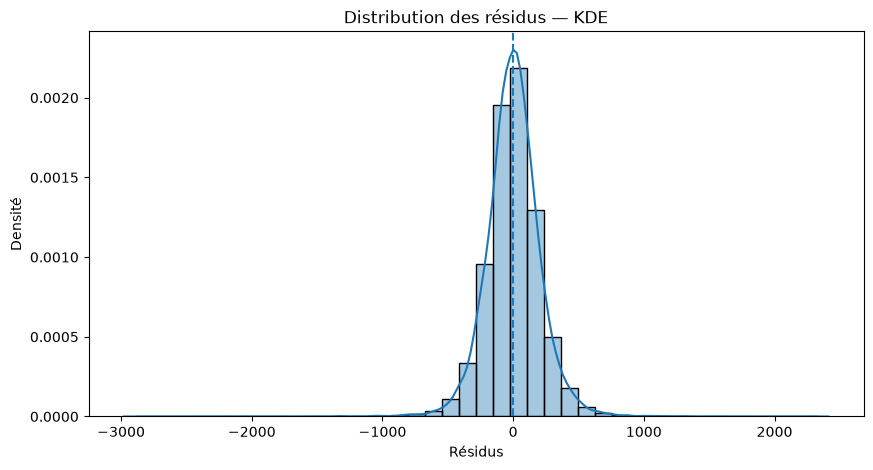

In [330]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

residuals = y_val_hd - pred_val_ridge_hd

plt.figure(figsize=(10, 5))

sns.histplot(residuals, bins=40, stat="density", alpha=0.4)
sns.kdeplot(residuals, bw_adjust=1)

plt.axvline(0, linestyle="--")

plt.xlabel("Résidus")
plt.ylabel("Densité")
plt.title("Distribution des résidus — KDE")

plt.show()

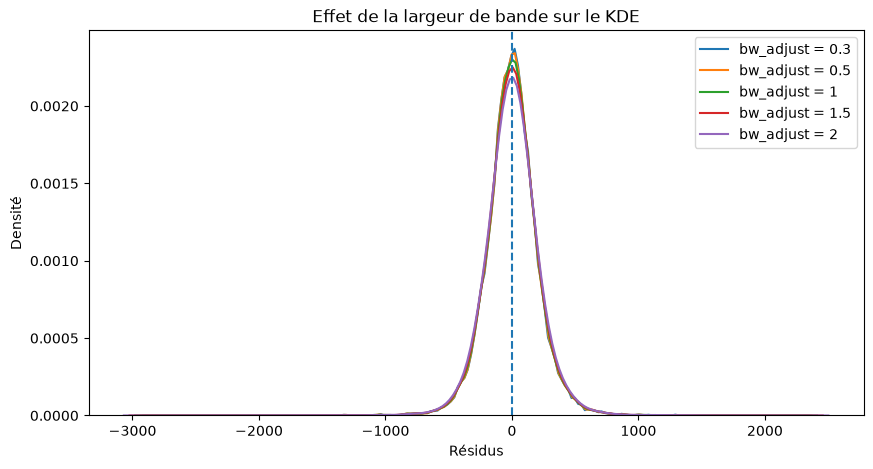

In [331]:
plt.figure(figsize=(10, 5))

for bw in [0.3, 0.5, 1, 1.5, 2]:
    sns.kdeplot(
        residuals,
        bw_adjust=bw,
        label=f"bw_adjust = {bw}"
    )

plt.axvline(0, linestyle="--")
plt.xlabel("Résidus")
plt.ylabel("Densité")
plt.title("Effet de la largeur de bande sur le KDE")
plt.legend()
plt.show()

In [332]:
print("Moyenne des résidus :", residuals.mean())
print("Médiane des résidus :", np.median(residuals))
print("Écart-type :", residuals.std())
print("Erreur min :", residuals.min())
print("Erreur max :", residuals.max())

Moyenne des résidus : 1.9448846503324504
Médiane des résidus : 1.9013638411997817
Écart-type : 211.12884313331992
Erreur min : -2888.935062891316
Erreur max : 2322.231963390768


### Interprétation des résidus

Les résidus sont globalement centrés autour de zéro
(moyenne ≈ 1.94, médiane ≈ 1.90), ce qui indique
l'absence de biais systématique important du modèle Ridge.

La distribution est principalement unimodale et relativement
symétrique, avec un écart-type d'environ 211.

Cependant, certaines erreurs extrêmes sont observées
(min ≈ -2889, max ≈ 2322), ce qui suggère que le modèle
rencontre des difficultés sur certaines périodes spécifiques.

La comparaison de plusieurs largeurs de bande KDE montre que
la forme générale de la distribution reste stable, ce qui renforce
l'idée d'une structure principale unique des résidus.

## Nonparametric Residual Analysis and Feature Engineering

In [335]:
from statsmodels.nonparametric.smoothers_lowess import lowess

residual_analysis = pd.DataFrame({
    "y_true": y_val_hd,
    "y_pred": pred_val_ridge_hd,
    "residual": y_val_hd - pred_val_ridge_hd
})

residual_analysis["hour"] = residual_analysis.index.hour

smoothed = lowess(
    endog=residual_analysis["residual"],
    exog=residual_analysis["hour"],
    frac=0.25,
    return_sorted=True
)

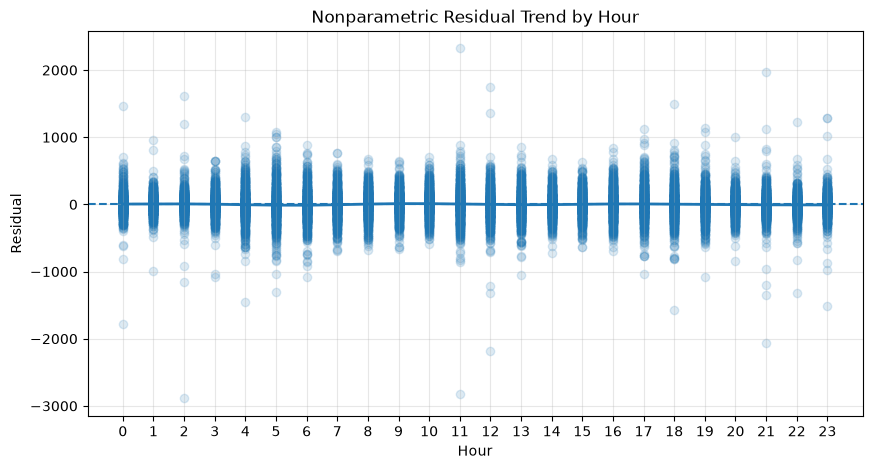

In [336]:
plt.figure(figsize=(10, 5))

plt.scatter(
    residual_analysis["hour"],
    residual_analysis["residual"],
    alpha=0.15
)

plt.plot(
    smoothed[:, 0],
    smoothed[:, 1],
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.xlabel("Hour")
plt.ylabel("Residual")
plt.title("Nonparametric Residual Trend by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

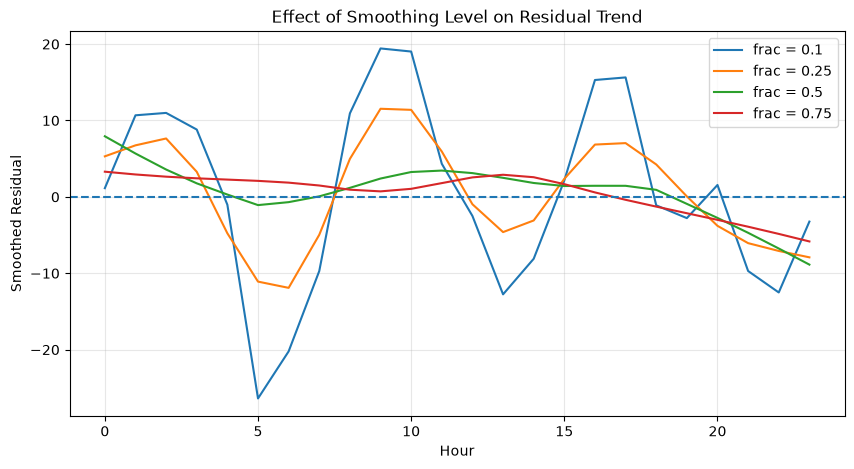

In [337]:
plt.figure(figsize=(10, 5))

for frac in [0.1, 0.25, 0.5, 0.75]:
    smoothed = lowess(
        residual_analysis["residual"],
        residual_analysis["hour"],
        frac=frac,
        return_sorted=True
    )

    plt.plot(
        smoothed[:, 0],
        smoothed[:, 1],
        label=f"frac = {frac}"
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Hour")
plt.ylabel("Smoothed Residual")
plt.title("Effect of Smoothing Level on Residual Trend")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The nonparametric residual trend remains close to zero across
the different hours of the day.

Compared with the overall residual standard deviation, the
remaining hourly bias is very small, indicating that the Ridge
model already captures most of the systematic hourly structure.

Lower smoothing levels produce stronger local fluctuations,
illustrating the bias-variance trade-off. However, these
fluctuations remain small relative to the overall prediction
error and are likely to represent noise rather than a strong
remaining temporal pattern.

Therefore, an additional hour-based residual correction is not
retained at this stage.

### Nonparametric Residual Analysis by Predicted Demand

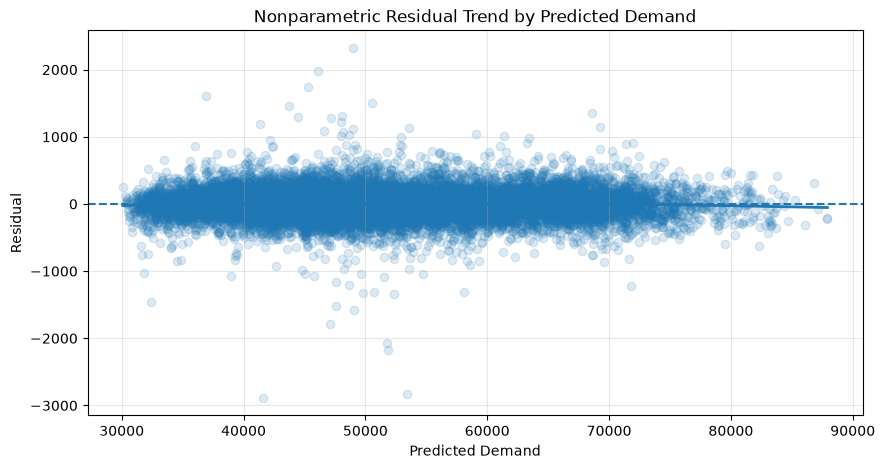

In [338]:
from statsmodels.nonparametric.smoothers_lowess import lowess

smoothed_pred = lowess(
    endog=residual_analysis["residual"],
    exog=residual_analysis["y_pred"],
    frac=0.25,
    return_sorted=True
)

plt.figure(figsize=(10, 5))

plt.scatter(
    residual_analysis["y_pred"],
    residual_analysis["residual"],
    alpha=0.15
)

plt.plot(
    smoothed_pred[:, 0],
    smoothed_pred[:, 1],
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Demand")
plt.ylabel("Residual")
plt.title("Nonparametric Residual Trend by Predicted Demand")

plt.grid(alpha=0.3)
plt.show()

### Interpretation

The smoothed residual trend remains close to zero across the
predicted demand range, suggesting that the Ridge model does not
exhibit a strong systematic bias as a function of predicted demand.

However, the spread of the residuals is not perfectly constant.
Prediction errors appear more dispersed for some intermediate
demand levels, while the dispersion is smaller at very high
predicted demand levels.

This suggests potential heteroscedasticity: the conditional
variance of the residuals may depend on the predicted demand.

### 3. Nonparametric Analysis of Residual Variance

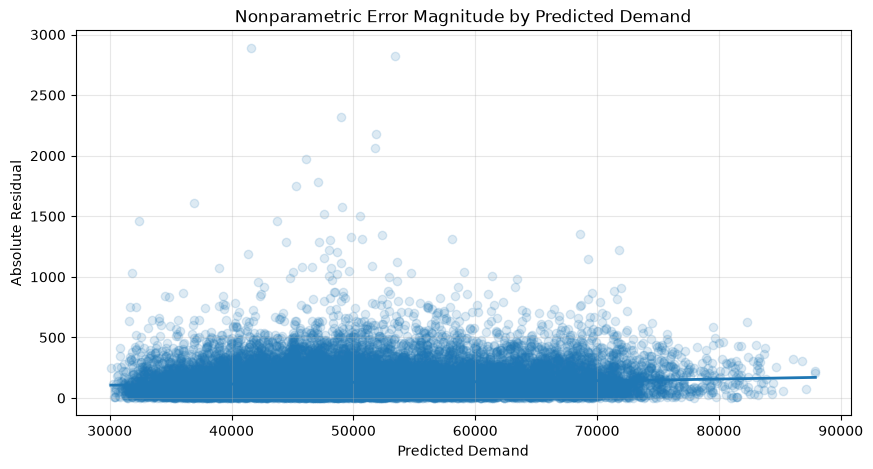

In [339]:
residual_analysis["abs_residual"] = np.abs(
    residual_analysis["residual"]
)

smoothed_abs = lowess(
    endog=residual_analysis["abs_residual"],
    exog=residual_analysis["y_pred"],
    frac=0.25,
    return_sorted=True
)

plt.figure(figsize=(10, 5))

plt.scatter(
    residual_analysis["y_pred"],
    residual_analysis["abs_residual"],
    alpha=0.15
)

plt.plot(
    smoothed_abs[:, 0],
    smoothed_abs[:, 1],
    linewidth=2
)

plt.xlabel("Predicted Demand")
plt.ylabel("Absolute Residual")
plt.title("Nonparametric Error Magnitude by Predicted Demand")

plt.grid(alpha=0.3)
plt.show()

### Interpretation

The absolute residuals are not perfectly constant across the
predicted demand range.

The nonparametric trend remains relatively stable for most
predicted demand levels, but increases slightly for the highest
predicted values.

This suggests the presence of moderate heteroscedasticity:
the magnitude of the prediction errors may depend on the level
of predicted demand.

However, the number of observations is lower in the highest
demand range, so this increase should be interpreted cautiously.

### 4. Breusch-Pagan Test for Heteroscedasticity

In [340]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X_bp = sm.add_constant(residual_analysis["y_pred"])

bp_test = het_breuschpagan(
    residual_analysis["residual"],
    X_bp
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

dict(zip(labels, bp_test))

{'LM Statistic': np.float64(16.102479512262747),
 'LM p-value': np.float64(6.000542086553831e-05),
 'F Statistic': np.float64(16.1154529021685),
 'F p-value': np.float64(5.9843868086727714e-05)}

### Interpretation

The Breusch-Pagan test strongly rejects the null hypothesis of
constant residual variance.

LM p-value ≈ 6.0e-05
F p-value ≈ 5.98e-05

Since both p-values are well below 0.05, there is statistical
evidence of heteroscedasticity in the Ridge residuals.

Therefore, while the model is approximately unbiased, the
uncertainty of its predictions is not constant across demand
levels.

### 5. Conditional Residual Variance Analysis

In [341]:
residual_analysis["demand_bin"] = pd.qcut(
    residual_analysis["y_pred"],
    q=10,
    duplicates="drop"
)

variance_by_demand = (
    residual_analysis
    .groupby("demand_bin", observed=True)
    .agg(
        mean_prediction=("y_pred", "mean"),
        residual_variance=("residual", "var"),
        residual_std=("residual", "std"),
        mae=("abs_residual", "mean"),
        count=("residual", "size")
    )
)

variance_by_demand

,mean_prediction,residual_variance,residual_std,mae,count
demand_bin,,,,,
"(30093.127, 37778.252]",35170.387924,31554.572859,177.636069,127.096143,1752
"(37778.252, 41378.349]",39698.381168,33922.955007,184.181853,134.443030,1752
"(41378.349, 44245.586]",42851.797768,41183.315754,202.936728,146.007448,1752
"(44245.586, 46555.614]",45423.205604,41823.544592,204.508055,148.811534,1752
"(46555.614, 48847.613]",47706.200442,48404.652112,220.010573,156.096238,1752
"(48847.613, 51558.579]",50171.485231,51284.020689,226.459755,161.580720,1752
"(51558.579, 55367.996]",53299.010425,53793.484294,231.934224,158.800514,1752
"(55367.996, 60447.487]",57747.082644,49177.496625,221.759998,164.941074,1752
"(60447.487, 66495.749]",63421.747627,42096.805621,205.175061,157.906001,1752


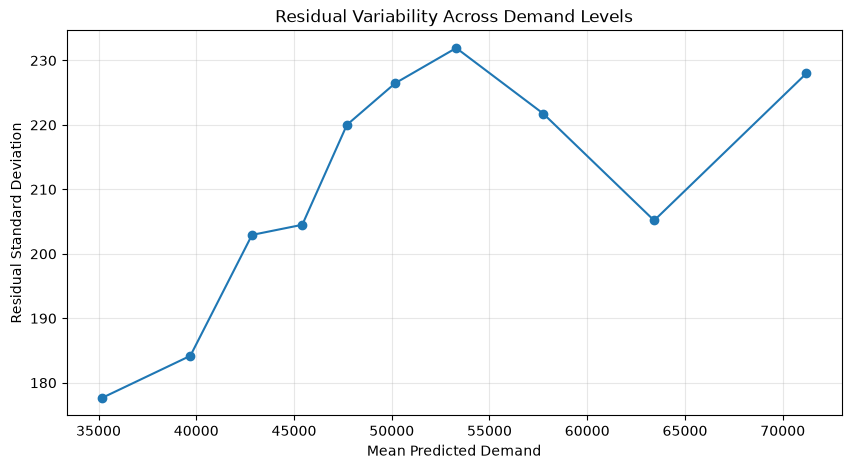

In [342]:
plt.figure(figsize=(10, 5))

plt.plot(
    variance_by_demand["mean_prediction"],
    variance_by_demand["residual_std"],
    marker="o"
)

plt.xlabel("Mean Predicted Demand")
plt.ylabel("Residual Standard Deviation")
plt.title("Residual Variability Across Demand Levels")
plt.grid(alpha=0.3)

plt.show()

### Interpretation

Residual variability clearly depends on the predicted demand level.

The residual standard deviation increases from approximately 178
for low-demand observations to more than 230 for intermediate
demand levels, before decreasing and increasing again for the
highest-demand observations.

The MAE follows a similar pattern, ranging from approximately
127 to 173.

Therefore, the heteroscedasticity detected by the Breusch-Pagan
test is also practically meaningful. However, the relationship
between demand and residual variance is non-monotonic, suggesting
that a simple variance-stabilizing transformation may not fully
capture the phenomenon.

## Heteroscedasticity-Aware Weighted Ridge Regression

### 1. Out-of-Fold Residual Variance Estimation

In [343]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

In [344]:
tscv = TimeSeriesSplit(n_splits=5)

oof_pred = np.full(len(y_train_hd), np.nan)

for train_idx, valid_idx in tscv.split(X_train_hd):

    model_fold = clone(ridge_hd)

    model_fold.fit(
        X_train_hd.iloc[train_idx],
        y_train_hd.iloc[train_idx]
    )

    oof_pred[valid_idx] = model_fold.predict(
        X_train_hd.iloc[valid_idx]
    )

In [345]:
mask_oof = ~np.isnan(oof_pred)

oof_analysis = pd.DataFrame({
    "y_true": np.asarray(y_train_hd)[mask_oof],
    "y_pred": oof_pred[mask_oof]
})

oof_analysis["residual"] = (
    oof_analysis["y_true"]
    - oof_analysis["y_pred"]
)

oof_analysis["squared_residual"] = (
    oof_analysis["residual"] ** 2
)

oof_analysis["abs_residual"] = np.abs(
    oof_analysis["residual"]
)

oof_analysis.head()

,y_true,y_pred,residual,squared_residual,abs_residual
0,81389.0,82033.973798,-644.973798,415991.200223,644.973798
1,81341.0,81481.068463,-140.068463,19619.174352,140.068463
2,80858.0,81077.917576,-219.917576,48363.740144,219.917576
3,80593.0,80379.721209,213.278791,45487.842817,213.278791
4,80013.0,80316.459244,-303.459244,92087.512496,303.459244


### 2. Nonparametric Variance Function Estimation

In [347]:
from statsmodels.nonparametric.smoothers_lowess import lowess

variance_curve = lowess(
    endog=oof_analysis["squared_residual"],
    exog=oof_analysis["y_pred"],
    frac=0.25,
    delta=500,
    return_sorted=True
)

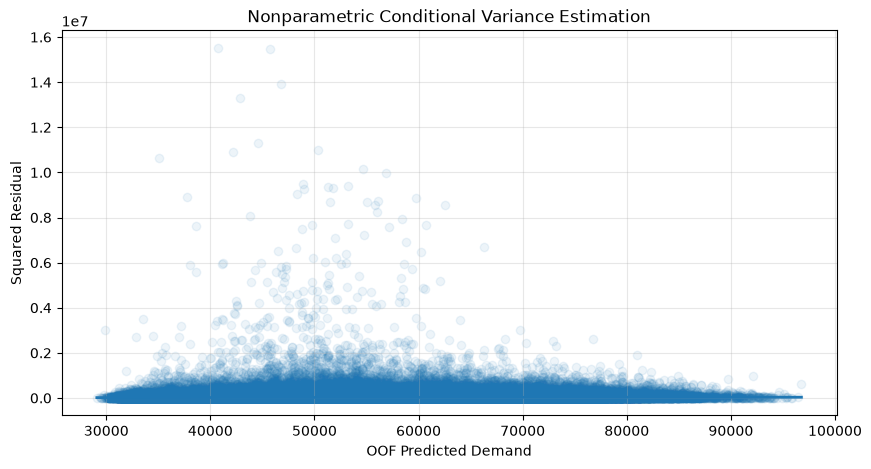

In [348]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    oof_analysis["y_pred"],
    oof_analysis["squared_residual"],
    alpha=0.08
)

plt.plot(
    variance_curve[:, 0],
    variance_curve[:, 1],
    linewidth=2
)

plt.xlabel("OOF Predicted Demand")
plt.ylabel("Squared Residual")
plt.title("Nonparametric Conditional Variance Estimation")
plt.grid(alpha=0.3)

plt.show()

### 3. Construction of Heteroscedasticity-Aware Weights

In [349]:
from scipy.interpolate import interp1d

variance_function = interp1d(
    variance_curve[:, 0],
    variance_curve[:, 1],
    kind="linear",
    bounds_error=False,
    fill_value=(
        variance_curve[0, 1],
        variance_curve[-1, 1]
    )
)

In [350]:
base_ridge_full = clone(ridge_hd)

base_ridge_full.fit(
    X_train_hd,
    y_train_hd
)

train_pred_for_weights = base_ridge_full.predict(
    X_train_hd
)

In [351]:
estimated_variance = variance_function(
    train_pred_for_weights
)

In [352]:
variance_floor = np.percentile(
    estimated_variance,
    5
)

estimated_variance = np.maximum(
    estimated_variance,
    variance_floor
)

In [353]:
sample_weights = 1 / estimated_variance

In [354]:
sample_weights = (
    sample_weights
    / np.mean(sample_weights)
)

In [355]:
print("Poids min :", sample_weights.min())
print("Poids max :", sample_weights.max())
print("Poids moyen :", sample_weights.mean())

Poids min : 0.712380552891189
Poids max : 1.2800298712469633
Poids moyen : 1.0000000000000002


### 4. Weighted Ridge Training

In [357]:
ridge_hd.named_steps

{'scaler': StandardScaler(), 'model': Ridge()}

In [362]:
Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(...))
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",Ellipsis
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [366]:
from sklearn.base import clone

weighted_ridge_hd = clone(ridge_hd)

weighted_ridge_hd.fit(
    X_train_hd,
    y_train_hd,
    model__sample_weight=sample_weights
)

pred_val_weighted_ridge_hd = weighted_ridge_hd.predict(X_val_hd)

In [367]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Ridge",
        "Weighted Ridge"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val_hd, pred_val_ridge_hd)),
        np.sqrt(mean_squared_error(y_val_hd, pred_val_weighted_ridge_hd))
    ],
    "MAE": [
        mean_absolute_error(y_val_hd, pred_val_ridge_hd),
        mean_absolute_error(y_val_hd, pred_val_weighted_ridge_hd)
    ],
    "R2": [
        r2_score(y_val_hd, pred_val_ridge_hd),
        r2_score(y_val_hd, pred_val_weighted_ridge_hd)
    ]
})

comparison

,Model,RMSE,MAE,R2
0,Ridge,211.131776,152.872991,0.999605
1,Weighted Ridge,211.399015,152.940902,0.999604


In [368]:
print("Poids min :", sample_weights.min())
print("Poids max :", sample_weights.max())
print("Poids moyen :", sample_weights.mean())

Poids min : 0.712380552891189
Poids max : 1.2800298712469633
Poids moyen : 1.0000000000000002


### 5. Weighted Ridge Validation Performance

In [369]:
pred_val_weighted_ridge_hd = weighted_ridge_hd.predict(
    X_val_hd
)

In [370]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse_weighted = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_val_weighted_ridge_hd
    )
)

mae_weighted = mean_absolute_error(
    y_val_hd,
    pred_val_weighted_ridge_hd
)

r2_weighted = r2_score(
    y_val_hd,
    pred_val_weighted_ridge_hd
)

print("Weighted Ridge")
print("RMSE :", rmse_weighted)
print("MAE  :", mae_weighted)
print("R²   :", r2_weighted)

Weighted Ridge
RMSE : 211.39901473681786
MAE  : 152.94090211961986
R²   : 0.9996038990552715


In [372]:
comparison = pd.DataFrame({
    "Model": [
        "Ridge",
        "Heteroscedasticity-Aware Weighted Ridge"
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_val_hd,
                pred_val_ridge_hd
            )
        ),
        rmse_weighted
    ],
    "MAE": [
        mean_absolute_error(
            y_val_hd,
            pred_val_ridge_hd
        ),
        mae_weighted
    ],
    "R2": [
        r2_score(
            y_val_hd,
            pred_val_ridge_hd
        ),
        r2_weighted
    ]
})

comparison

,Model,RMSE,MAE,R2
0,Ridge,211.131776,152.872991,0.999605
1,Heteroscedasticity-Aware Weighted Ridge,211.399015,152.940902,0.999604


In [373]:
import joblib

joblib.dump(
    {
        "oof_pred": oof_pred,
        "variance_curve": variance_curve,
        "sample_weights": sample_weights,
        "weighted_model": weighted_ridge_hd,
        "pred_val_weighted": pred_val_weighted_ridge_hd,
        "comparison": comparison
    },
    "weighted_ridge_results.joblib"
)

['weighted_ridge_results.joblib']

### Model Comparison and Decision

The heteroscedasticity-aware Weighted Ridge does not improve
validation performance compared with the standard Ridge model.

| Model | RMSE | MAE | R² |
|---|---:|---:|---:|
| Ridge | 211.13 | 152.87 | 0.999605 |
| Weighted Ridge | 211.40 | 152.94 | 0.999604 |

Although heteroscedasticity was statistically detected, weighting
the observations according to their estimated conditional variance
slightly degraded both RMSE and MAE.

This suggests that heteroscedasticity mainly affects the uncertainty
of the predictions rather than the conditional mean itself.

Therefore, the standard Ridge model is retained for point prediction.

## Adaptive Prediction Intervals from Conditional Residual Variance

### 1. Conditional Standard Deviation Estimation

In [374]:
val_variance_est = variance_function(pred_val_ridge_hd)

val_variance_est = np.maximum(
    val_variance_est,
    1e-8
)

val_sigma_est = np.sqrt(
    val_variance_est
)

### 2. Adaptive 95% Prediction Intervals

In [375]:
z = 1.96

lower_95 = (
    pred_val_ridge_hd
    - z * val_sigma_est
)

upper_95 = (
    pred_val_ridge_hd
    + z * val_sigma_est
)

In [376]:
coverage_95 = np.mean(
    (np.asarray(y_val_hd) >= lower_95)
    &
    (np.asarray(y_val_hd) <= upper_95)
)

avg_width_95 = np.mean(
    upper_95 - lower_95
)

print("Adaptive interval")
print("Coverage :", coverage_95)
print("Average width :", avg_width_95)

Adaptive interval
Coverage : 0.8864726027397261
Average width : 610.3316977220171


### 3. Adaptive Interval Visualization

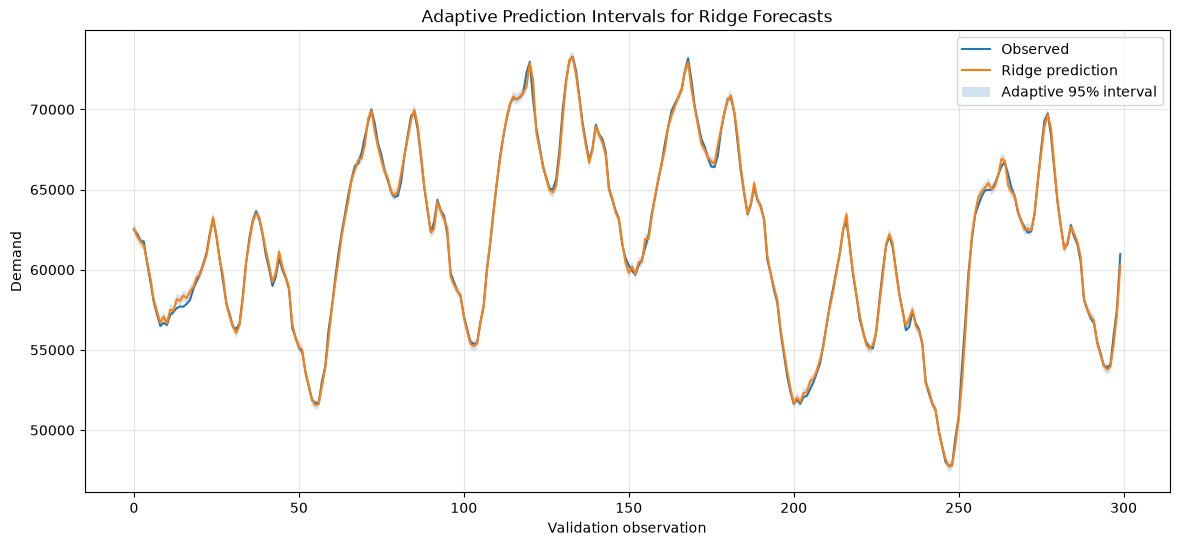

In [377]:
n_plot = 300

y_val_array = np.asarray(y_val_hd)

plt.figure(figsize=(14, 6))

plt.plot(
    np.arange(n_plot),
    y_val_array[:n_plot],
    label="Observed"
)

plt.plot(
    np.arange(n_plot),
    pred_val_ridge_hd[:n_plot],
    label="Ridge prediction"
)

plt.fill_between(
    np.arange(n_plot),
    lower_95[:n_plot],
    upper_95[:n_plot],
    alpha=0.2,
    label="Adaptive 95% interval"
)

plt.xlabel("Validation observation")
plt.ylabel("Demand")
plt.title(
    "Adaptive Prediction Intervals for Ridge Forecasts"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4. Adaptive vs Constant Prediction Intervals

In [378]:
global_sigma = residuals.std()

lower_const = (
    pred_val_ridge_hd
    - 1.96 * global_sigma
)

upper_const = (
    pred_val_ridge_hd
    + 1.96 * global_sigma
)

coverage_const = np.mean(
    (np.asarray(y_val_hd) >= lower_const)
    &
    (np.asarray(y_val_hd) <= upper_const)
)

avg_width_const = np.mean(
    upper_const - lower_const
)

comparison_intervals = pd.DataFrame({
    "Method": [
        "Constant interval",
        "Adaptive interval"
    ],
    "Coverage": [
        coverage_const,
        coverage_95
    ],
    "Average Width": [
        avg_width_const,
        avg_width_95
    ]
})

comparison_intervals

,Method,Coverage,Average Width
0,Constant interval,0.952226,827.625065
1,Adaptive interval,0.886473,610.331698


### Interpretation

The adaptive prediction intervals are substantially narrower than
the constant intervals (approximately 610 vs 828 on average).

However, their empirical coverage is only 88.65%, well below the
target 95% level.

Therefore, the Gaussian multiplier 1.96 is not sufficient for the
estimated conditional residual distribution.

This motivates an empirical calibration of the adaptive intervals
using out-of-fold residuals.

## Empirically Calibrated Adaptive Prediction Intervals

### 1. Standardized Out-of-Fold Residuals

In [379]:
oof_variance_est = variance_function(
    oof_analysis["y_pred"]
)

oof_variance_est = np.maximum(
    oof_variance_est,
    1e-8
)

oof_sigma_est = np.sqrt(
    oof_variance_est
)

standardized_oof_errors = (
    np.abs(oof_analysis["residual"])
    / oof_sigma_est
)

In [380]:
print(
    pd.Series(standardized_oof_errors).describe(
        percentiles=[0.90, 0.95, 0.975, 0.99]
    )
)

count    175040.000000
mean          1.169335
std           1.130561
min           0.000007
90%           2.450593
95%           3.125528
97.5%         3.887276
99%           5.056135
max          26.779736
Name: residual, dtype: float64


### 2. Empirical 95% Calibration

In [381]:
q95 = np.quantile(
    standardized_oof_errors,
    0.95
)

print("Empirical 95% multiplier :", q95)
print("Gaussian multiplier      :", 1.96)

Empirical 95% multiplier : 3.125528498323874
Gaussian multiplier      : 1.96


In [382]:
lower_calibrated = (
    pred_val_ridge_hd
    - q95 * val_sigma_est
)

upper_calibrated = (
    pred_val_ridge_hd
    + q95 * val_sigma_est
)

In [383]:
coverage_calibrated = np.mean(
    (np.asarray(y_val_hd) >= lower_calibrated)
    &
    (np.asarray(y_val_hd) <= upper_calibrated)
)

width_calibrated = np.mean(
    upper_calibrated - lower_calibrated
)

print("Calibrated adaptive coverage :", coverage_calibrated)
print("Calibrated average width     :", width_calibrated)

Calibrated adaptive coverage : 0.9731735159817352
Calibrated average width     : 973.2699564594674


### 3. Final Prediction Interval Comparison

In [384]:
final_interval_comparison = pd.DataFrame({
    "Method": [
        "Constant Gaussian",
        "Adaptive Gaussian",
        "Adaptive Empirically Calibrated"
    ],
    "Coverage": [
        coverage_const,
        coverage_95,
        coverage_calibrated
    ],
    "Average Width": [
        avg_width_const,
        avg_width_95,
        width_calibrated
    ]
})

final_interval_comparison

,Method,Coverage,Average Width
0,Constant Gaussian,0.952226,827.625065
1,Adaptive Gaussian,0.886473,610.331698
2,Adaptive Empirically Calibrated,0.973174,973.269956


### Final Interpretation

The empirical calibration reveals that the standardized residuals
have heavier tails than a Gaussian distribution.

The empirical 95% multiplier is approximately 3.13, substantially
larger than the Gaussian value of 1.96.

The calibrated adaptive intervals achieve high empirical coverage
(97.32%), but their average width increases to approximately 973,
which is wider than the constant Gaussian interval (approximately
828).

Therefore, the adaptive conditional-variance approach does not
improve the coverage-width trade-off on the validation set.

The constant Gaussian interval remains the preferred uncertainty
quantification method among the approaches tested.

## Final Statistical Assessment of the Ridge Model

### 1. Summary of Residual Diagnostics

The Ridge residuals are globally well centered around zero, with a
mean and median close to zero. This indicates that the model does
not exhibit a strong global systematic bias.

Kernel Density Estimation confirmed that the residual distribution
is mainly unimodal and approximately symmetric, although several
large residuals remain present.

The bandwidth sensitivity analysis showed that the global shape of
the residual distribution is stable across different smoothing
levels.

### 2. Nonparametric Residual Structure

Nonparametric smoothing of the residuals according to the hour of
day showed that the conditional mean residual remains close to zero.

Similarly, the residual trend with respect to predicted demand does
not reveal a strong nonlinear bias.

Therefore, the Ridge model already captures most of the systematic
structure of the conditional mean.

### 3. Heteroscedasticity Analysis

The Breusch-Pagan test detected statistically significant
heteroscedasticity in the residuals.

The conditional residual standard deviation varied across demand
levels, confirming that prediction uncertainty is not constant.

However, the relationship between predicted demand and residual
variance was not strictly monotonic.

### 4. Heteroscedasticity-Aware Weighted Ridge

A heteroscedasticity-aware Weighted Ridge model was trained using
weights derived from a nonparametric estimate of the conditional
residual variance.

The weighted model did not improve validation performance.

In [385]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Ridge",
        "Heteroscedasticity-Aware Weighted Ridge"
    ],
    "RMSE": [
        211.131776,
        211.399015
    ],
    "MAE": [
        152.872991,
        152.940902
    ],
    "R2": [
        0.999605,
        0.999604
    ]
})

final_model_comparison

,Model,RMSE,MAE,R2
0,Ridge,211.131776,152.872991,0.999605
1,Heteroscedasticity-Aware Weighted Ridge,211.399015,152.940902,0.999604


The standard Ridge model remains slightly better in terms of both
RMSE and MAE.

Therefore, the weighted version is not retained for final point
prediction.

### 5. Prediction Interval Evaluation

In [386]:
final_interval_comparison = pd.DataFrame({
    "Method": [
        "Constant Gaussian",
        "Adaptive Gaussian",
        "Adaptive Empirically Calibrated"
    ],
    "Coverage": [
        0.952226,
        0.886473,
        0.973174
    ],
    "Average Width": [
        827.625065,
        610.331698,
        973.269956
    ]
})

final_interval_comparison

,Method,Coverage,Average Width
0,Constant Gaussian,0.952226,827.625065
1,Adaptive Gaussian,0.886473,610.331698
2,Adaptive Empirically Calibrated,0.973174,973.269956


The adaptive Gaussian intervals were substantially narrower than
the constant intervals, but their empirical coverage was too low.

Empirical calibration restored and even exceeded the target
coverage, but produced substantially wider intervals.

Therefore, among the tested approaches, the constant Gaussian
interval provides the best practical coverage-width trade-off.

### 6. Final Methodological Decision

The final point-prediction model remains the standard Ridge model.

The nonparametric analysis revealed statistically significant
heteroscedasticity, but exploiting this structure through weighted
regression did not improve predictive accuracy.

Similarly, adaptive prediction intervals did not improve the
coverage-width trade-off compared with the simpler constant
interval.

These experiments therefore provide additional statistical insight
into the model without justifying a replacement of the baseline
Ridge predictor.

### 7. Link with Nonparametric Statistical Theory

This analysis directly applies concepts from nonparametric density
estimation and bias-variance theory.

Kernel Density Estimation was used to study the residual
distribution and the effect of the bandwidth parameter.

Nonparametric smoothing was then used to investigate conditional
residual trends and estimate the conditional variance.

These analyses demonstrate how nonparametric statistical tools can
be used not only for estimation, but also for model diagnostics,
uncertainty analysis, and data-driven model improvement.

In [387]:
import joblib

joblib.dump(
    {
        "ridge_model": ridge_hd,
        "weighted_ridge_model": weighted_ridge_hd,
        "oof_predictions": oof_pred,
        "variance_curve": variance_curve,
        "sample_weights": sample_weights,
        "ridge_validation_predictions": pred_val_ridge_hd,
        "weighted_validation_predictions": pred_val_weighted_ridge_hd,
        "model_comparison": final_model_comparison,
        "interval_comparison": final_interval_comparison
    },
    "block1_nonparametric_analysis.joblib"
)

['block1_nonparametric_analysis.joblib']

## 11. Lasso en haute dimension

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np

lasso_hd = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        max_iter=3000,
        tol=1e-3,
        selection="random",
        random_state=42
    ))
])

# Seulement 3 folds
tscv = TimeSeriesSplit(n_splits=3)

# Première recherche grossière : seulement 7 valeurs
params_lasso = {
    "model__alpha": np.logspace(-2, 2, 7)
}

grid_lasso_hd = GridSearchCV(
    lasso_hd,
    params_lasso,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)



In [ ]:
lasso_path = os.path.join(
    models_folder,
    "grid_lasso_hd.joblib"
)

if os.path.exists(lasso_path):
    grid_lasso_hd = joblib.load(lasso_path)
    print("Modèle Lasso chargé")
else:
    grid_lasso_hd.fit(X_train_hd, y_train_hd)
    joblib.dump(grid_lasso_hd, lasso_path)
    print("Modèle Lasso entraîné et sauvegardé")

Modèle Lasso chargé


In [ ]:
print("Meilleur alpha Lasso HD :", grid_lasso_hd.best_params_)
print("CV RMSE Lasso HD :", -grid_lasso_hd.best_score_)

Meilleur alpha Lasso HD : {'model__alpha': np.float64(1.0)}
CV RMSE Lasso HD : 423.2758438279854


Meilleur alpha Lasso HD : {'model__alpha': np.float64(1.0)}
CV RMSE Lasso HD : 428.4778036330283

In [ ]:
pred_val_lasso_hd = grid_lasso_hd.predict(X_val_hd)

rmse_lasso_hd = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_lasso_hd)
)

mae_lasso_hd = mean_absolute_error(
    y_val_hd, pred_val_lasso_hd
)

print("Lasso HD RMSE :", rmse_lasso_hd)
print("Lasso HD MAE :", mae_lasso_hd)

Lasso HD RMSE : 380.0390436638016
Lasso HD MAE : 279.1009209676949


Lasso HD RMSE : 388.7846766942992
Lasso HD MAE : 284.55302029873565

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np

lasso_fine = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        max_iter=3000,
        tol=1e-3,
        selection="random",
        random_state=42
    ))
])

# Seulement 3 folds
tscv = TimeSeriesSplit(n_splits=3)

# Seconde recherche : seulement 9 valeurs
params_lasso_fine = {
    "model__alpha": [
        0.1,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0,
        1.2,
        1.5,
        2.0
    ]
}

grid_lasso_fine = GridSearchCV(
    lasso_hd,
    params_lasso_fine,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)


In [ ]:
import os
import joblib

lasso_path_fine = os.path.join(
    models_folder,
    "grid_lasso_fine.joblib"
)

if os.path.exists(lasso_path_fine):
    grid_lasso_fine = joblib.load(lasso_path_fine)
    print("Modèle Lasso chargé")
else:
    grid_lasso_fine.fit(X_train_hd, y_train_hd)
    joblib.dump(grid_lasso_fine, lasso_path_fine)
    print("Modèle Lasso entraîné et sauvegardé")


Modèle Lasso chargé


In [ ]:
print("Meilleur alpha Lasso Fine :", grid_lasso_fine.best_params_)
print("CV RMSE Lasso Fine:", -grid_lasso_fine.best_score_)

Meilleur alpha Lasso Fine : {'model__alpha': 1.2}
CV RMSE Lasso Fine: 421.4663905530683


In [ ]:
pred_val_lasso_fine = grid_lasso_fine.predict(X_val_hd)

rmse_lasso_fine = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_lasso_fine)
)

mae_lasso_fine = mean_absolute_error(
    y_val_hd,
    pred_val_lasso_fine
)

print("Lasso fin RMSE :", rmse_lasso_fine)
print("Lasso fin MAE :", mae_lasso_fine)

Lasso fin RMSE : 377.5694840786671
Lasso fin MAE : 277.52452821431694


In [ ]:
best_lasso = grid_lasso_hd.best_estimator_

coef_lasso = best_lasso.named_steps["model"].coef_

n_selected = np.sum(coef_lasso != 0)

print("Nombre total de variables :", X_train_hd.shape[1])
print("Nombre de variables sélectionnées :", n_selected)

Nombre total de variables : 361
Nombre de variables sélectionnées : 271


In [ ]:
coef_lasso_series = pd.Series(
    coef_lasso,
    index=X_train_hd.columns
)

selected_lasso = (
    coef_lasso_series[coef_lasso_series != 0]
    .sort_values(key=abs, ascending=False)
)

print(selected_lasso.head(30))

lag_1             7218.556957
lag_220           3654.659840
lag_3             2608.470141
lag_48            2539.735337
lag_2             2471.099028
rolling_mean_6    1828.303543
lag_288           1725.903920
lag_240           1576.141684
lag_221          -1519.004659
lag_154           1510.423104
lag_50           -1286.730682
lag_51           -1283.627573
lag_143           1106.386418
lag_96            1059.130222
lag_4            -1014.194295
lag_291           -993.973067
lag_290           -988.736720
lag_333            977.391041
lag_218           -906.670016
lag_5             -905.433096
lag_219           -871.530268
lag_106           -849.072307
lag_28            -848.902469
lag_192            807.244087
lag_241           -744.960210
lag_289           -724.821545
lag_49            -723.708228
lag_264           -701.605384
lag_336           -673.953332
lag_190            669.331039
dtype: float64


In [ ]:
coef_lasso = grid_lasso_hd.best_estimator_[
    "model"
].coef_

n_selected = np.sum(coef_lasso != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected)
print(
    "Pourcentage conservé :",
    100 * n_selected / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 271
Pourcentage conservé : 75.06925207756233


Conclusion : L’ajout de lags saisonniers améliore légèrement Ridge, ce qui montre que l’historique à long terme apporte une information supplémentaire, même si l’essentiel du signal est déjà contenu dans les observations récentes. Lasso conserve 271 variables sur 361, soit environ 75 % des features, tout en restant nettement moins performant que Ridge. Ces résultats indiquent que le problème est peu sparse et que la consommation électrique dépend de nombreux prédicteurs temporels corrélés. Dans cette situation, la régularisation \(L_2\) de Ridge est beaucoup mieux adaptée que la sélection agressive induite par Lasso.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

alphas = np.logspace(-2, 2, 50)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=tscv,
        alphas=alphas,
        max_iter=5000,
        tol=1e-3,
        n_jobs=-1
    ))
])


In [ ]:
model.fit(X_train_hd, y_train_hd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](361,)","['lag_1','lag_2','lag_3',...,'dow_cos','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,361
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
best_alpha = model.named_steps["lasso"].alpha_

print("Meilleur alpha :", best_alpha)

Meilleur alpha : 1.5998587196060574


In [ ]:
print(model.named_steps["lasso"].alphas_)

[1.00000000e+02 8.28642773e+01 6.86648845e+01 5.68986603e+01
 4.71486636e+01 3.90693994e+01 3.23745754e+01 2.68269580e+01
 2.22299648e+01 1.84206997e+01 1.52641797e+01 1.26485522e+01
 1.04811313e+01 8.68511374e+00 7.19685673e+00 5.96362332e+00
 4.94171336e+00 4.09491506e+00 3.39322177e+00 2.81176870e+00
 2.32995181e+00 1.93069773e+00 1.59985872e+00 1.32571137e+00
 1.09854114e+00 9.10298178e-01 7.54312006e-01 6.25055193e-01
 5.17947468e-01 4.29193426e-01 3.55648031e-01 2.94705170e-01
 2.44205309e-01 2.02358965e-01 1.67683294e-01 1.38949549e-01
 1.15139540e-01 9.54095476e-02 7.90604321e-02 6.55128557e-02
 5.42867544e-02 4.49843267e-02 3.72759372e-02 3.08884360e-02
 2.55954792e-02 2.12095089e-02 1.75751062e-02 1.45634848e-02
 1.20679264e-02 1.00000000e-02]


In [ ]:
pred_val_lassocv = model.predict(X_val_hd)

rmse_lassocv = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_lassocv)
)

mae_lassocv = mean_absolute_error(
    y_val_hd, pred_val_lassocv
)

print("LassoCV RMSE :", rmse_lassocv)
print("LassoCV MAE :", mae_lassocv)

LassoCV RMSE : 390.3486181997979
LassoCV MAE : 300.4679911677652


In [ ]:
coef_lassocv = model.named_steps["lasso"].coef_

n_selected_lassocv = np.sum(coef_lassocv != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected_lassocv)
print(
    "Pourcentage conservé :",
    100 * n_selected_lassocv / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 243
Pourcentage conservé : 67.31301939058172


## 12. Elastic Net en haute dimension

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np
import os
import joblib

elastic_hd = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        max_iter=5000,
        tol=1e-3
    ))
])

tscv = TimeSeriesSplit(n_splits=3)

params_elastic = {
    "model__alpha": [0.3, 1.0, 2.0],
    "model__l1_ratio": [0.05, 0.1, 0.3]
}

grid_elastic_hd = GridSearchCV(
    elastic_hd,
    params_elastic,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [ ]:
models_folder = os.path.join(os.getcwd(), "models")
os.makedirs(models_folder, exist_ok=True)

elastic_path = os.path.join(
    models_folder,
    "grid_elastic_hd_seasonal.joblib"
)

if os.path.exists(elastic_path):
    grid_elastic_hd = joblib.load(elastic_path)
    print("Modèle Elastic Net chargé")

else:
    grid_elastic_hd.fit(X_train_hd, y_train_hd)

    joblib.dump(
        grid_elastic_hd,
        elastic_path
    )

    print("Modèle Elastic Net entraîné et sauvegardé")

Modèle Elastic Net chargé


In [ ]:
pred_val_elastic = grid_elastic_hd.predict(X_val_hd)

rmse_elastic = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_elastic)
)

mae_elastic = mean_absolute_error(
    y_val_hd, pred_val_elastic
)

print("Elastic Net RMSE :", rmse_elastic)
print("Elastic Net MAE :", mae_elastic)

Elastic Net RMSE : 1167.485240832083
Elastic Net MAE : 891.5033795053292


In [ ]:
best_elastic = grid_elastic_hd.best_estimator_

coef_elastic = best_elastic.named_steps["model"].coef_

n_selected_elastic = np.sum(coef_elastic != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected_elastic)
print(
    "Pourcentage conservé :",
    100 * n_selected_elastic / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 359
Pourcentage conservé : 99.44598337950139


In [ ]:
from sklearn.linear_model import ElasticNetCV

model = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.05, 0.1, 0.3, 0.5],
        cv=tscv,
        alphas=30,
        max_iter=5000,
        tol=1e-3,
        n_jobs=-1
    ))
])

In [ ]:
model.fit(X_train_hd, y_train_hd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('elastic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](361,)","['lag_1','lag_2','lag_3',...,'dow_cos','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,361
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
elastic_model = model.named_steps["elastic"]

print("Meilleur alpha :", elastic_model.alpha_)
print("Meilleur l1_ratio :", elastic_model.l1_ratio_)

Meilleur alpha : 23.22915619313125
Meilleur l1_ratio : 0.5


In [ ]:
print(model.named_steps)

{'scaler': StandardScaler(), 'elastic': ElasticNetCV(alphas=30,
             cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             l1_ratio=[0.05, 0.1, 0.3, 0.5], max_iter=5000, n_jobs=-1,
             tol=0.001)}


In [ ]:
pred_val_elasticcv = model.predict(X_val_hd)

rmse_elasticcv = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_elasticcv)
)

mae_elasticcv = mean_absolute_error(
    y_val_hd, pred_val_elasticcv
)

print("ElasticNetCV RMSE :", rmse_elasticcv)
print("ElasticNetCV MAE :", mae_elasticcv)

ElasticNetCV RMSE : 3632.7252559167814
ElasticNetCV MAE : 2911.2852758703593


In [ ]:
coef_elasticcv = model.named_steps["elastic"].coef_

n_selected_elasticcv = np.sum(coef_elasticcv != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected_elasticcv)
print(
    "Pourcentage conservé :",
    100 * n_selected_elasticcv / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 350
Pourcentage conservé : 96.95290858725762


In [ ]:
elastic = model.named_steps["elastic"]

print("Alpha minimum :", elastic.alphas_.min())
print("Alpha maximum :", elastic.alphas_.max())
print("Nombre d'alphas :", elastic.alphas_.shape)

Alpha minimum : 23.22915619313125
Alpha maximum : 232291.5619313125
Nombre d'alphas : (4, 30)


In [ ]:
alphas = np.logspace(-3, 1, 25)

model_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.05, 0.1, 0.3, 0.5],
        cv=tscv,
        alphas=alphas,
        max_iter=5000,
        tol=1e-3,
        n_jobs=-1
    ))
])

In [ ]:
elasticcv_path = os.path.join(
    models_folder,
    "elasticnetcv_hd_seasonal.joblib"
)

if os.path.exists(elasticcv_path):
    model_elastic = joblib.load(elasticcv_path)
    print("ElasticNetCV chargé")

else:
    model_elastic.fit(X_train_hd, y_train_hd)

    joblib.dump(
        model_elastic,
        elasticcv_path
    )

    print("ElasticNetCV entraîné et sauvegardé")

ElasticNetCV chargé


In [ ]:
elastic_model = model_elastic.named_steps["elastic"]

print("Meilleur alpha :", elastic_model.alpha_)
print("Meilleur l1_ratio :", elastic_model.l1_ratio_)

Meilleur alpha : 0.0014677992676220691
Meilleur l1_ratio : 0.1


In [ ]:
pred_val_elastic = model_elastic.predict(X_val_hd)

rmse_elastic = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_elastic)
)

mae_elastic = mean_absolute_error(
    y_val_hd, pred_val_elastic
)

print("ElasticNetCV RMSE :", rmse_elastic)
print("ElasticNetCV MAE :", mae_elastic)

ElasticNetCV RMSE : 335.7492299803974
ElasticNetCV MAE : 244.7851242265041


In [ ]:
coef_elastic = model_elastic.named_steps["elastic"].coef_

n_selected = np.sum(coef_elastic != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected)
print(
    "Pourcentage conservé :",
    100 * n_selected / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 361
Pourcentage conservé : 100.0


In [ ]:
alphas = np.logspace(-3, 1, 25)

model_elastic2 = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.001, 0.005, 0.01, 0.05, 0.1],
        cv=tscv,
        alphas=alphas,
        max_iter=5000,
        tol=1e-3,
        n_jobs=-1
    ))
])

In [ ]:
elasticcv_path2 = os.path.join(
    models_folder,
    "elasticnetcv2_hd_seasonal.joblib"
)

if os.path.exists(elasticcv_path2):
    model_elastic2 = joblib.load(elasticcv_path2)
    print("ElasticNetCV chargé")

else:
    model_elastic2.fit(X_train_hd, y_train_hd)

    joblib.dump(
        model_elastic2,
        elasticcv_path2
    )

    print("ElasticNetCV entraîné et sauvegardé")

ElasticNetCV chargé


In [ ]:
elastic_model2 = model_elastic2.named_steps["elastic"]

print("Meilleur alpha :", elastic_model2.alpha_)
print("Meilleur l1_ratio :", elastic_model2.l1_ratio_)

Meilleur alpha : 0.0014677992676220691
Meilleur l1_ratio : 0.1


In [ ]:
pred_val_elastic = model_elastic2.predict(X_val_hd)

rmse_elastic2 = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_elastic)
)

mae_elastic2 = mean_absolute_error(
    y_val_hd, pred_val_elastic
)

print("ElasticNetCV RMSE :", rmse_elastic2)
print("ElasticNetCV MAE :", mae_elastic2)

ElasticNetCV RMSE : 335.7492299803974
ElasticNetCV MAE : 244.7851242265041


In [ ]:
coef_elastic = model_elastic.named_steps["elastic"].coef_

n_selected = np.sum(coef_elastic != 0)

print("Variables totales :", X_train_hd.shape[1])
print("Variables sélectionnées :", n_selected)
print(
    "Pourcentage conservé :",
    100 * n_selected / X_train_hd.shape[1]
)

Variables totales : 361
Variables sélectionnées : 361
Pourcentage conservé : 100.0


Conclusion : Elastic Net améliore nettement les performances de Lasso grâce à l’ajout d’une composante \(L_2\), mais reste moins performant que Ridge. Cela confirme que, pour cette série, il est préférable de conserver l’ensemble des variables corrélées en réduisant leurs coefficients plutôt que d’imposer une forte sélection de variables.

## 13. PCA + Régression linéaire

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

pcr = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LinearRegression())
])

pcr.fit(X_train_hd, y_train_hd)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](361,)","['lag_1','lag_2','lag_3',...,'dow_cos','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,361
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
n_components = pcr.named_steps["pca"].n_components_

print("Nombre de variables initiales :", X_train_hd.shape[1])
print("Nombre de composantes PCA :", n_components)

Nombre de variables initiales : 361
Nombre de composantes PCA : 11


In [ ]:
pred_val_pcr = pcr.predict(X_val_hd)

rmse_pcr = np.sqrt(
    mean_squared_error(y_val_hd, pred_val_pcr)
)

mae_pcr = mean_absolute_error(
    y_val_hd, pred_val_pcr
)

print("PCA + OLS RMSE :", rmse_pcr)
print("PCA + OLS MAE :", mae_pcr)

PCA + OLS RMSE : 2560.5929863759575
PCA + OLS MAE : 1949.7769938403574


In [ ]:
explained_variance = (
    pcr.named_steps["pca"]
    .explained_variance_ratio_
    .sum()
)

print("Variance expliquée :", explained_variance)

Variance expliquée : 0.9506874162009076


Conclusion : La PCA réduit extrêmement bien la dimension, passant de 361 variables à seulement 11 composantes tout en conservant environ 95 % de la variance. Cependant, cette compression dégrade fortement la qualité prédictive, avec un RMSE d’environ 2561 MW contre 211 MW pour Ridge. Cela montre que conserver la majorité de la variance de \(X\) ne garantit pas de conserver l’information pertinente pour prédire \(y\). Dans ce problème, Ridge est donc largement préférable à PCA + OLS.

## 14. Comparaison finale des modèles

In [ ]:
results = pd.DataFrame({
    "Model": [
        "OLS HD",
        "Ridge HD",
        "Lasso fin",
        "ElasticNetCV",
        "PCA + OLS"
    ],
    "RMSE": [
        211.30886635995526,
        211.13177572735984,
        377.5694840786671,
        335.7492299803974,
        2560.5929863759575
    ],
    "MAE": [
        153.1332756201532,
        152.8729908554616,
        277.52452821431694,
        244.7851242265041,
        1949.7769938403574
    ]
})

results.sort_values("RMSE")

,Model,RMSE,MAE
1,Ridge HD,211.131776,152.872991
0,OLS HD,211.308866,153.133276
3,ElasticNetCV,335.749230,244.785124
2,Lasso fin,377.569484,277.524528
4,PCA + OLS,2560.592986,1949.776994


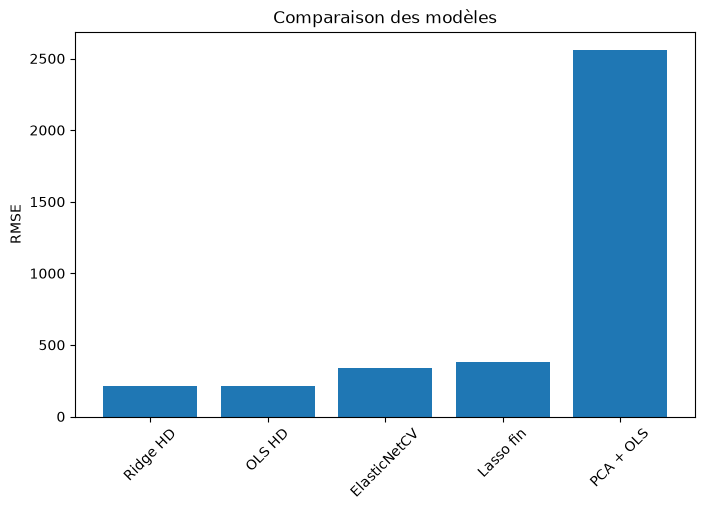

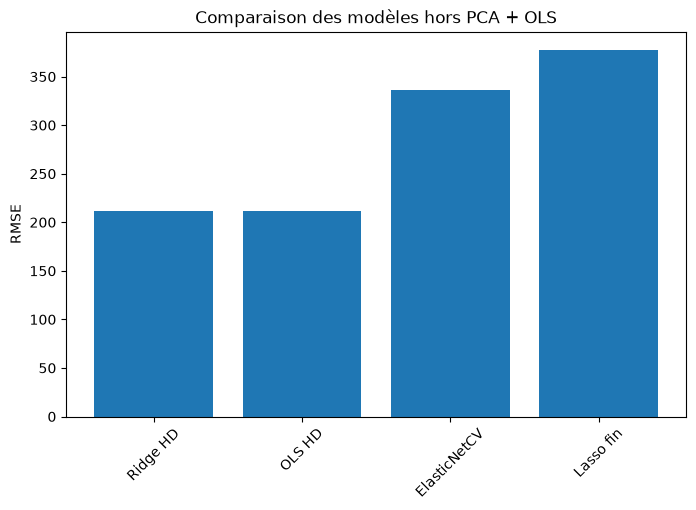

In [ ]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values("RMSE")

plt.figure(figsize=(8, 5))
plt.bar(results_sorted["Model"], results_sorted["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparaison des modèles")
plt.xticks(rotation=45)
plt.show()

results_no_pca = results[
    results["Model"] != "PCA + OLS"
].sort_values("RMSE")

plt.figure(figsize=(8, 5))
plt.bar(
    results_no_pca["Model"],
    results_no_pca["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Comparaison des modèles hors PCA + OLS")
plt.xticks(rotation=45)
plt.show()

Conclusion : Hors PCA, Ridge et OLS obtiennent des performances très proches et dominent largement les modèles contenant une pénalisation \(L_1\). Elastic Net améliore Lasso mais reste nettement derrière, ce qui confirme que le problème est peu sparse et que la conservation des variables corrélées est préférable à leur sélection agressive.

## 15. Ensembling des modèles

In [ ]:
pred_val_ensemble_simple = (
    pred_val_ridge_hd
    + pred_val_ols_hd
) / 2

In [ ]:
rmse_ensemble_simple = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_val_ensemble_simple
    )
)

mae_ensemble_simple = mean_absolute_error(
    y_val_hd,
    pred_val_ensemble_simple
)

print("Ensemble simple RMSE :", rmse_ensemble_simple)
print("Ensemble simple MAE :", mae_ensemble_simple)

Ensemble simple RMSE : 211.0193227469647
Ensemble simple MAE : 152.83421044863726


In [ ]:
pred_val_ensemble_weighted = (
    0.7 * pred_val_ridge_hd
    + 0.3 * pred_val_ols_hd
)

In [ ]:
rmse_ensemble_weighted = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_val_ensemble_weighted
    )
)

mae_ensemble_weighted = mean_absolute_error(
    y_val_hd,
    pred_val_ensemble_weighted
)

print("Ensemble pondéré RMSE :", rmse_ensemble_weighted)
print("Ensemble pondéré MAE :", mae_ensemble_weighted)

Ensemble pondéré RMSE : 211.06307900087
Ensemble pondéré MAE : 152.8486151711236


In [ ]:
weights = np.arange(0, 1.01, 0.05)

results_ensemble = []

for w in weights:

    pred = (
        w * pred_val_ridge_hd
        + (1 - w) * pred_val_ols_hd
    )

    rmse = np.sqrt(
        mean_squared_error(y_val_hd, pred)
    )

    results_ensemble.append(
        [w, rmse]
    )

ensemble_df = pd.DataFrame(
    results_ensemble,
    columns=[
        "weight_ridge",
        "rmse"
    ]
)

print(
    ensemble_df.sort_values("rmse").head()
)

   weight_ridge        rmse
0          0.00  210.917085
1          0.05  210.926849
2          0.10  210.936715
3          0.15  210.946683
4          0.20  210.956753


In [ ]:
best_row = ensemble_df.loc[
    ensemble_df["rmse"].idxmin()
]

print("Meilleur poids Ridge :", best_row["weight_ridge"])
print("Meilleur RMSE :", best_row["rmse"])

Meilleur poids Ridge : 0.0
Meilleur RMSE : 210.91708492807564


In [ ]:
res_ridge = y_val_hd - pred_val_ridge_hd
res_ols = y_val_hd - pred_val_ols_hd
res_lasso = y_val_hd - pred_val_lasso_fine
res_elastic = y_val_hd - pred_val_elastic

In [ ]:
residuals = pd.DataFrame({
    "Ridge": res_ridge,
    "OLS": res_ols,
    "Lasso": res_lasso,
    "ElasticNet": res_elastic
})

print(residuals.corr())

               Ridge       OLS     Lasso  ElasticNet
Ridge       1.000000  0.999903  0.619683    0.695585
OLS         0.999903  1.000000  0.612844    0.688556
Lasso       0.619683  0.612844  1.000000    0.962670
ElasticNet  0.695585  0.688556  0.962670    1.000000


In [ ]:
from scipy.optimize import minimize
import numpy as np

predictions = np.column_stack([
    pred_val_ridge_hd,
    pred_val_ols_hd,
    pred_val_lasso_fine,
    pred_val_elastic
])

def objective(weights):
    pred = predictions @ weights
    return np.sqrt(
        mean_squared_error(y_val_hd, pred)
    )

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [(0, 1)] * predictions.shape[1]

initial_weights = np.ones(
    predictions.shape[1]
) / predictions.shape[1]

result = minimize(
    objective,
    initial_weights,
    bounds=bounds,
    constraints=constraints
)

print("Poids optimaux :", result.x)
print("RMSE ensemble :", result.fun)

Poids optimaux : [2.24545771e-10 1.00000000e+00 0.00000000e+00 0.00000000e+00]
RMSE ensemble : 210.91708482767996


In [ ]:
pred_ensemble_opt = predictions @ result.x

mae_ensemble_opt = mean_absolute_error(
    y_val_hd,
    pred_ensemble_opt
)

print("MAE ensemble :", mae_ensemble_opt)

MAE ensemble : 152.80294430124704


Conclusion : L’optimisation des poids attribue pratiquement 100 % du poids à OLS et 0 % aux autres modèles. Malgré une plus grande diversité d’erreurs pour Lasso et Elastic Net, leurs performances individuelles sont trop faibles pour améliorer l’ensemble. L’ensembling n’apporte donc pas de gain significatif ici, et OLS reste le meilleur modèle sur la validation.

## 16. Stacking avec prédictions OOF

### 16.1 Définition des modèles de base

In [ ]:
base_models = {
    "OLS": LinearRegression(),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=17.4))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.00147,
            l1_ratio=0.1,
            max_iter=1000,
            tol=1e-2
        ))
    ])
}


### 16.2 Définition de la validation temporelle

In [ ]:
tscv_stack = TimeSeriesSplit(n_splits=3)

### 16.3 Initialisation de la matrice OOF

In [ ]:
Z_oof = np.full(
    (len(X_train_hd), len(base_models)),
    np.nan
)

y_oof = np.full(
    len(X_train_hd),
    np.nan
)

### 16.4 Génération des prédictions OOF

In [ ]:
from sklearn.base import clone
import time

for fold, (train_idx, val_idx) in enumerate(
    tscv_stack.split(X_train_hd),
    start=1
):
    print(f"\n===== Fold {fold} =====")

    X_fold_train = X_train_hd.iloc[train_idx]
    y_fold_train = y_train_hd.iloc[train_idx]

    X_fold_val = X_train_hd.iloc[val_idx]
    y_fold_val = y_train_hd.iloc[val_idx]

    for j, (name, model) in enumerate(base_models.items()):

        print(f"Début : {name}")
        start = time.time()

        model_fold = clone(model)

        model_fold.fit(
            X_fold_train,
            y_fold_train
        )

        pred_fold = model_fold.predict(
            X_fold_val
        )

        Z_oof[val_idx, j] = pred_fold

        elapsed = time.time() - start

        print(
            f"Fin : {name} "
            f"({elapsed:.1f} secondes)"
        )

    y_oof[val_idx] = y_fold_val.values


===== Fold 1 =====
Début : OLS
Fin : OLS (10.8 secondes)
Début : Ridge
Fin : Ridge (2.5 secondes)
Début : ElasticNet
Fin : ElasticNet (3.3 secondes)

===== Fold 2 =====
Début : OLS
Fin : OLS (8.7 secondes)
Début : Ridge
Fin : Ridge (4.9 secondes)
Début : ElasticNet
Fin : ElasticNet (6.3 secondes)

===== Fold 3 =====
Début : OLS
Fin : OLS (13.9 secondes)
Début : Ridge
Fin : Ridge (4.0 secondes)
Début : ElasticNet
Fin : ElasticNet (7.5 secondes)


### 16.5 Nettoyage et construction de Z_oof

In [ ]:
valid_oof = ~np.isnan(Z_oof).any(axis=1)

Z_oof_clean = Z_oof[valid_oof]
y_oof_clean = y_oof[valid_oof]

In [ ]:
print("Z_oof :", Z_oof_clean.shape)
print("y_oof :", y_oof_clean.shape)

Z_oof : (157536, 3)
y_oof : (157536,)


In [ ]:
Z_oof_df = pd.DataFrame(
    Z_oof_clean,
    columns=base_models.keys()
)

print(Z_oof_df.head())

            OLS         Ridge    ElasticNet
0  62106.446133  62157.046126  62844.663070
1  61343.952846  61374.823956  60341.231062
2  60777.223639  60770.751212  59938.091510
3  60600.664859  60367.448078  59378.990496
4  58558.057168  58638.870005  58884.218423


In [ ]:
### 16.6 Entraînement du méta-modèle

In [ ]:
meta_model = Ridge(alpha=1.0)

meta_model.fit(
    Z_oof_clean,
    y_oof_clean
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [ ]:
meta_coef = pd.Series(
    meta_model.coef_,
    index=base_models.keys()
)

print(meta_coef)
print("Intercept :", meta_model.intercept_)

OLS           0.951987
Ridge         0.049480
ElasticNet   -0.001380
dtype: float64
Intercept : -12.384745803748956


In [ ]:
# Réentraîner les modèles de base sur tout le train

fitted_models = {}

for name, model in base_models.items():
    
    model_full = clone(model)
    
    model_full.fit(
        X_train_hd,
        y_train_hd
    )
    
    fitted_models[name] = model_full

In [ ]:
# Prédictions sur la validation 2025

Z_val = np.column_stack([
    fitted_models["OLS"].predict(X_val_hd),
    fitted_models["Ridge"].predict(X_val_hd),
    fitted_models["ElasticNet"].predict(X_val_hd)
])

In [ ]:
pred_stacking = meta_model.predict(Z_val)

In [ ]:
rmse_stacking = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_stacking
    )
)

mae_stacking = mean_absolute_error(
    y_val_hd,
    pred_stacking
)

print("Stacking RMSE :", rmse_stacking)
print("Stacking MAE :", mae_stacking)

Stacking RMSE : 211.36893258381454
Stacking MAE : 153.11847364797015


Conclusion : Le stacking OOF n’améliore pas les performances par rapport à OLS ou Ridge pris individuellement. Le méta-modèle attribue presque tout le poids à OLS, une faible contribution à Ridge et quasiment aucune à Elastic Net. Cela montre que les modèles de base les plus performants produisent des prédictions trop similaires pour qu’un stacking apporte un gain significatif.

## 17. Hyperparameter tuning avancé

### 17.1 Optimisation avancée de Ridge

In [ ]:
alphas_ridge_coarse = np.logspace(-4, 5, 20)

In [ ]:
ridge_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

tscv_tuning = TimeSeriesSplit(n_splits=3)

grid_ridge_coarse = GridSearchCV(
    ridge_tuned,
    {
        "model__alpha": alphas_ridge_coarse
    },
    cv=tscv_tuning,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

In [ ]:
ridge_coarse_path = os.path.join(
    models_folder,
    "grid_ridge_coarse.joblib"
)

if os.path.exists(ridge_coarse_path):

    grid_ridge_coarse = joblib.load(
        ridge_coarse_path
    )

    print("Ridge coarse chargé")

else:

    grid_ridge_coarse.fit(
        X_train_hd,
        y_train_hd
    )

    joblib.dump(
        grid_ridge_coarse,
        ridge_coarse_path
    )

    print("Ridge coarse entraîné et sauvegardé")

Ridge coarse chargé


In [ ]:
best_alpha_coarse = grid_ridge_coarse.best_params_["model__alpha"]

print("Meilleur alpha coarse :", best_alpha_coarse)
print(
    "CV RMSE coarse :",
    -grid_ridge_coarse.best_score_
)

Meilleur alpha coarse : 0.2069138081114788
CV RMSE coarse : 254.47626236832446


In [ ]:
alphas_ridge_fine = np.logspace(
    np.log10(best_alpha_coarse) - 0.5,
    np.log10(best_alpha_coarse) + 0.5,
    15
)

In [ ]:
grid_ridge_fine = GridSearchCV(
    ridge_tuned,
    {
        "model__alpha": alphas_ridge_fine
    },
    cv=tscv_tuning,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)



In [ ]:
ridge_fine_path = os.path.join(
    models_folder,
    "grid_ridge_fine.joblib"
)

if os.path.exists(ridge_fine_path):

    grid_ridge_fine = joblib.load(
        ridge_fine_path
    )

    print("Ridge fine chargé")

else:

    grid_ridge_fine.fit(
        X_train_hd,
        y_train_hd
    )

    joblib.dump(
        grid_ridge_fine,
        ridge_fine_path
    )

    print("Ridge fine entraîné et sauvegardé")

Ridge fine chargé


In [ ]:
best_alpha_fine = grid_ridge_fine.best_params_["model__alpha"]

print("Meilleur alpha fin :", best_alpha_fine)
print(
    "CV RMSE fin :",
    -grid_ridge_fine.best_score_
)

Meilleur alpha fin : 0.3994880193954167
CV RMSE fin : 254.4569909182588


In [ ]:
pred_val_ridge_tuned = grid_ridge_fine.predict(X_val_hd)

rmse_ridge_tuned = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_val_ridge_tuned
    )
)

mae_ridge_tuned = mean_absolute_error(
    y_val_hd,
    pred_val_ridge_tuned
)

print("Ridge tuned RMSE :", rmse_ridge_tuned)
print("Ridge tuned MAE :", mae_ridge_tuned)

Ridge tuned RMSE : 211.0746986242047
Ridge tuned MAE : 152.85239066791326


### 17.2 Tuning fin de Ridge

In [ ]:
ridge_advanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

tscv_advanced = TimeSeriesSplit(n_splits=3)

params_ridge_advanced = {
    "model__alpha": np.linspace(0.1, 0.8, 12),
    "model__solver": [
        "auto",
        "lsqr"
    ]
}

In [ ]:
grid_ridge_advanced = GridSearchCV(
    ridge_advanced,
    params_ridge_advanced,
    cv=tscv_advanced,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=2
)

In [ ]:
models_folder = os.path.join(os.getcwd(), "models")
os.makedirs(models_folder, exist_ok=True)

ridge_advanced_path = os.path.join(
    models_folder,
    "grid_ridge_advanced.joblib"
)

if os.path.exists(ridge_advanced_path):

    grid_ridge_advanced = joblib.load(
        ridge_advanced_path
    )

    print("Ridge advanced chargé")

else:

    grid_ridge_advanced.fit(
        X_train_hd,
        y_train_hd
    )

    joblib.dump(
        grid_ridge_advanced,
        ridge_advanced_path
    )

    print("Ridge advanced entraîné et sauvegardé")

Ridge advanced chargé


In [ ]:
print(
    "Meilleurs paramètres :",
    grid_ridge_advanced.best_params_
)

print(
    "CV RMSE :",
    -grid_ridge_advanced.best_score_
)

Meilleurs paramètres : {'model__alpha': np.float64(0.4181818181818182), 'model__solver': 'auto'}
CV RMSE : 254.45739257501637


In [ ]:
pred_val_ridge_advanced = (
    grid_ridge_advanced.predict(X_val_hd)
)

rmse_ridge_advanced = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_val_ridge_advanced
    )
)

mae_ridge_advanced = mean_absolute_error(
    y_val_hd,
    pred_val_ridge_advanced
)

print(
    "Ridge Advanced RMSE :",
    rmse_ridge_advanced
)

print(
    "Ridge Advanced MAE :",
    mae_ridge_advanced
)

Ridge Advanced RMSE : 211.08253147993773
Ridge Advanced MAE : 152.85510741677015


Conclusion : Le tuning avancé de Ridge confirme un optimum autour de \(\alpha \approx 0.4\), mais les performances restent pratiquement inchangées par rapport au tuning précédent. Le modèle a donc atteint un plateau : poursuivre l’optimisation de l’hyperparamètre alpha aurait peu de chances d’apporter un gain notable. Les prochaines améliorations devront plutôt venir du feature engineering ou de modèles plus flexibles.

## 18. Modèles non linéaires

### 18.1 HistGradientBoosting — modèle de référence

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
hist_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=42
)

In [ ]:
models_folder = os.path.join(
    os.getcwd(),
    "models"
)

os.makedirs(
    models_folder,
    exist_ok=True
)

hist_path = os.path.join(
    models_folder,
    "hist_gradient_boosting_baseline.joblib"
)

In [ ]:
if os.path.exists(hist_path):

    hist_model = joblib.load(hist_path)

    print(
        "HistGradientBoosting chargé"
    )

else:

    hist_model.fit(
        X_train_hd,
        y_train_hd
    )

    joblib.dump(
        hist_model,
        hist_path
    )

    print(
        "HistGradientBoosting entraîné et sauvegardé"
    )

HistGradientBoosting chargé


In [ ]:
pred_hist = hist_model.predict(
    X_val_hd
)

rmse_hist = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_hist
    )
)

mae_hist = mean_absolute_error(
    y_val_hd,
    pred_hist
)

print(
    "HistGradientBoosting RMSE :",
    rmse_hist
)

print(
    "HistGradientBoosting MAE :",
    mae_hist
)

HistGradientBoosting RMSE : 390.15082530951133
HistGradientBoosting MAE : 298.2201530613661


Conclusion : Le HistGradientBoosting obtient des performances nettement inférieures à celles des modèles linéaires, avec un RMSE d’environ 390 MW. Dans cette configuration, les relations temporelles semblent être mieux capturées par les nombreux lags et une combinaison linéaire réguliarisée que par ce modèle d’arbres. Un autre modèle de boosting plus flexible peut néanmoins être testé avant de conclure sur les approches non linéaires.

### 18.2 XGBoost — baseline

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)


In [ ]:
models_folder = os.path.join(
    os.getcwd(),
    "models"
)

os.makedirs(
    models_folder,
    exist_ok=True
)

xgb_path = os.path.join(
    models_folder,
    "xgb_baseline.joblib"
)

In [ ]:
if os.path.exists(xgb_path):

    xgb_model = joblib.load(xgb_path)

    print("XGBoost chargé")

else:

    xgb_model.fit(
        X_train_hd,
        y_train_hd
    )

    joblib.dump(
        xgb_model,
        xgb_path
    )

    print("XGBoost entraîné et sauvegardé")

XGBoost chargé


In [ ]:
pred_xgb = xgb_model.predict(
    X_val_hd
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_val_hd,
        pred_xgb
    )
)

mae_xgb = mean_absolute_error(
    y_val_hd,
    pred_xgb
)

print(
    "XGBoost RMSE :",
    rmse_xgb
)

print(
    "XGBoost MAE :",
    mae_xgb
)

XGBoost RMSE : 346.13214578816746
XGBoost MAE : 264.20103586972033


Conclusion : XGBoost améliore le HistGradientBoosting mais reste nettement moins performant que Ridge et OLS. Les variables temporelles construites semblent déjà transformer le problème en une relation largement linéaire, ce qui favorise les modèles de régression linéaire régularisée. Un tuning intensif de XGBoost n’est donc pas prioritaire.

## 19. Feature engineering avancé

### 19.1 Différences entre lags

In [ ]:
df_model["diff_1"] = (
    df_model["lag_1"]
    - df_model["lag_2"]
)

df_model["diff_day"] = (
    df_model["lag_1"]
    - df_model["lag_48"]
)

df_model["diff_week"] = (
    df_model["lag_1"]
    - df_model["lag_336"]
)

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\4199044403.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["diff_1"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\4199044403.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["diff_day"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\4199044403.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

### 19.2 Tendances locales

In [ ]:
df_model["trend_3h"] = (
    df_model["lag_1"]
    - df_model["lag_6"]
)

df_model["trend_6h"] = (
    df_model["lag_1"]
    - df_model["lag_12"]
)

df_model["trend_12h"] = (
    df_model["lag_1"]
    - df_model["lag_24"]
)

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\411435468.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["trend_3h"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\411435468.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["trend_6h"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\411435468.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

### 19.3 Écart aux moyennes récentes

In [ ]:
df_model["dev_mean_3h"] = (
    df_model["lag_1"]
    - df_model["rolling_mean_6"]
)

df_model["dev_mean_day"] = (
    df_model["lag_1"]
    - df_model["rolling_mean_48"]
)

df_model["dev_mean_week"] = (
    df_model["lag_1"]
    - df_model["rolling_mean_336"]
)

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3524468545.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["dev_mean_3h"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3524468545.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["dev_mean_day"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\3524468545.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

### 19.4 Variabilité récente

In [ ]:
df_model["cv_day"] = (
    df_model["rolling_std_48"]
    / (df_model["rolling_mean_48"] + 1e-6)
)

df_model["cv_week"] = (
    df_model["rolling_std_336"]
    / (df_model["rolling_mean_336"] + 1e-6)
)

C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\1024921205.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["cv_day"] = (
C:\Users\thiba\AppData\Local\Temp\ipykernel_8596\1024921205.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["cv_week"] = (


In [ ]:
advanced_features = [
    "diff_1",
    "diff_day",
    "diff_week",
    "trend_3h",
    "trend_6h",
    "trend_12h",
    "dev_mean_3h",
    "dev_mean_day",
    "dev_mean_week",
    "cv_day",
    "cv_week"
]

In [ ]:
features_hd_advanced = (
    features_hd
    + advanced_features
)

In [ ]:
df_model_advanced = (
    df_model[
        ["Consommation (MW)"]
        + features_hd_advanced
    ]
    .dropna()
)

In [ ]:
X_hd_advanced = (
    df_model_advanced[
        features_hd_advanced
    ]
)

y_hd_advanced = (
    df_model_advanced[
        "Consommation (MW)"
    ]
)

In [ ]:
X_train_adv = X_hd_advanced[
    X_hd_advanced.index < "2025-01-01"
]

y_train_adv = y_hd_advanced[
    y_hd_advanced.index < "2025-01-01"
]

X_val_adv = X_hd_advanced[
    (X_hd_advanced.index >= "2025-01-01")
    &
    (X_hd_advanced.index < "2026-01-01")
]

y_val_adv = y_hd_advanced[
    (y_hd_advanced.index >= "2025-01-01")
    &
    (y_hd_advanced.index < "2026-01-01")
]

### 19.5 Ridge avec nouvelles features

In [ ]:
ridge_adv_features = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.3994880193954167))
])

In [ ]:
ridge_adv_features_path = os.path.join(
    models_folder,
    "ridge_advanced_features.joblib"
)

if os.path.exists(ridge_adv_features_path):

    ridge_adv_features = joblib.load(
        ridge_adv_features_path
    )

    print("Ridge advanced features chargé")

else:

    ridge_adv_features.fit(
        X_train_adv,
        y_train_adv
    )

    joblib.dump(
        ridge_adv_features,
        ridge_adv_features_path
    )

    print(
        "Ridge advanced features entraîné et sauvegardé"
    )

Ridge advanced features chargé


In [ ]:
pred_ridge_adv_features = (
    ridge_adv_features.predict(
        X_val_adv
    )
)

rmse_ridge_adv_features = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_ridge_adv_features
    )
)

mae_ridge_adv_features = (
    mean_absolute_error(
        y_val_adv,
        pred_ridge_adv_features
    )
)

print(
    "Ridge Advanced Features RMSE :",
    rmse_ridge_adv_features
)

print(
    "Ridge Advanced Features MAE :",
    mae_ridge_adv_features
)

Ridge Advanced Features RMSE : 210.893604890517
Ridge Advanced Features MAE : 152.81600755863204


Conclusion : L’ajout de variables décrivant les variations, tendances locales et écarts aux moyennes récentes améliore légèrement mais réellement les performances de Ridge. Le RMSE passe sous 211 MW, ce qui confirme que, sur ce problème, le feature engineering apporte davantage que l’optimisation très fine des hyperparamètres.

### 19.6 Analyse des nouvelles features

In [ ]:
ridge_coef = pd.Series(
    ridge_adv_features.named_steps["model"].coef_,
    index=features_hd_advanced
)

In [ ]:
advanced_coef = ridge_coef[
    advanced_features
].sort_values(
    key=np.abs,
    ascending=False
)

advanced_coef

dev_mean_week    1690.632598
dev_mean_day     1616.712317
diff_day        -1343.146219
dev_mean_3h      1249.984349
diff_week         870.390181
trend_12h         607.098595
trend_6h          517.322335
diff_1            445.204713
trend_3h           98.430483
cv_week            41.836012
cv_day            -35.511023
dtype: float64

In [ ]:
advanced_coef_df = pd.DataFrame({
    "feature": advanced_coef.index,
    "coefficient": advanced_coef.values,
    "abs_coefficient": np.abs(advanced_coef.values)
})

advanced_coef_df

,feature,coefficient,abs_coefficient
0,dev_mean_week,1690.632598,1690.632598
1,dev_mean_day,1616.712317,1616.712317
2,diff_day,-1343.146219,1343.146219
3,dev_mean_3h,1249.984349,1249.984349
4,diff_week,870.390181,870.390181
5,trend_12h,607.098595,607.098595
6,trend_6h,517.322335,517.322335
7,diff_1,445.204713,445.204713
8,trend_3h,98.430483,98.430483
9,cv_week,41.836012,41.836012


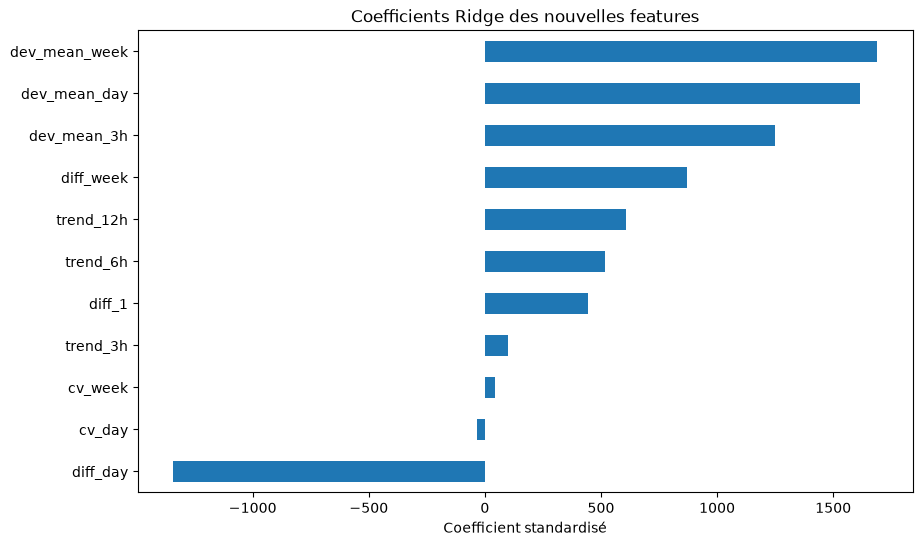

In [ ]:
plt.figure(figsize=(10, 6))

advanced_coef.sort_values().plot(
    kind="barh"
)

plt.title(
    "Coefficients Ridge des nouvelles features"
)

plt.xlabel(
    "Coefficient standardisé"
)

plt.show()

### 19.7 Ablation study des groupes de features

In [ ]:
feature_groups = {
    "Differences": [
        "diff_1",
        "diff_day",
        "diff_week"
    ],

    "Trends": [
        "trend_3h",
        "trend_6h",
        "trend_12h"
    ],

    "Deviations": [
        "dev_mean_3h",
        "dev_mean_day",
        "dev_mean_week"
    ],

    "Variability": [
        "cv_day",
        "cv_week"
    ]
}

In [ ]:
ablation_path = os.path.join(
    models_folder,
    "ablation_results.joblib"
)

if os.path.exists(ablation_path):

    ablation_results = joblib.load(
        ablation_path
    )

    ablation_df = pd.DataFrame(
        ablation_results
    ).sort_values("RMSE")

    print("Résultats d'ablation chargés")

else:

    ablation_results = []

    for group_name, group_features in feature_groups.items():

        selected_features = (
            features_hd
            + group_features
        )

        X_group = df_model_advanced[
            selected_features
        ]

        X_train_group = X_group[
            X_group.index < "2025-01-01"
        ]

        X_val_group = X_group[
            (X_group.index >= "2025-01-01")
            &
            (X_group.index < "2026-01-01")
        ]

        model_group = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(
                alpha=0.3994880193954167
            ))
        ])

        model_group.fit(
            X_train_group,
            y_train_adv
        )

        pred_group = model_group.predict(
            X_val_group
        )

        rmse_group = np.sqrt(
            mean_squared_error(
                y_val_adv,
                pred_group
            )
        )

        mae_group = mean_absolute_error(
            y_val_adv,
            pred_group
        )

        ablation_results.append({
            "Group": group_name,
            "RMSE": rmse_group,
            "MAE": mae_group
        })

    ablation_df = pd.DataFrame(
        ablation_results
    ).sort_values("RMSE")

    joblib.dump(
        ablation_results,
        ablation_path
    )

    print("Ablation study calculée et sauvegardée")

Résultats d'ablation chargés


In [ ]:
ablation_df = pd.DataFrame(
    ablation_results
).sort_values("RMSE")

ablation_df

,Group,RMSE,MAE
0,Differences,210.910248,152.774362
2,Deviations,210.937646,152.780490
1,Trends,211.001646,152.816107
3,Variability,211.050970,152.892150


Conclusion : L’ablation study montre que les variables de différences et d’écarts aux moyennes récentes apportent l’essentiel du gain de performance. Les tendances locales sont légèrement utiles, tandis que les coefficients de variation apportent très peu. Les meilleurs résultats sont toutefois obtenus en combinant l’ensemble des groupes, ce qui suggère que ces transformations fournissent des informations complémentaires.

### 19.8 Suppression des features peu utiles

In [ ]:
selected_advanced_features = [
    "diff_1",
    "diff_day",
    "diff_week",
    "trend_3h",
    "trend_6h",
    "trend_12h",
    "dev_mean_3h",
    "dev_mean_day",
    "dev_mean_week"
]

In [ ]:
features_hd_selected = (
    features_hd
    + selected_advanced_features
)

In [ ]:
df_model_selected = (
    df_model[
        ["Consommation (MW)"]
        + features_hd_selected
    ]
    .dropna()
)

X_selected = df_model_selected[
    features_hd_selected
]

y_selected = df_model_selected[
    "Consommation (MW)"
]

In [ ]:
X_train_selected = X_selected[
    X_selected.index < "2025-01-01"
]

y_train_selected = y_selected[
    y_selected.index < "2025-01-01"
]

X_val_selected = X_selected[
    (X_selected.index >= "2025-01-01")
    &
    (X_selected.index < "2026-01-01")
]

y_val_selected = y_selected[
    (y_selected.index >= "2025-01-01")
    &
    (y_selected.index < "2026-01-01")
]

In [ ]:
ridge_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(
        alpha=0.3994880193954167
    ))
])

In [ ]:
ridge_selected_path = os.path.join(
    models_folder,
    "ridge_selected_features.joblib"
)

if os.path.exists(ridge_selected_path):

    ridge_selected = joblib.load(
        ridge_selected_path
    )

    print("Ridge selected features chargé")

else:

    ridge_selected.fit(
        X_train_selected,
        y_train_selected
    )

    joblib.dump(
        ridge_selected,
        ridge_selected_path
    )

    print(
        "Ridge selected features entraîné et sauvegardé"
    )

Ridge selected features chargé


In [ ]:
pred_ridge_selected = ridge_selected.predict(
    X_val_selected
)

rmse_ridge_selected = np.sqrt(
    mean_squared_error(
        y_val_selected,
        pred_ridge_selected
    )
)

mae_ridge_selected = mean_absolute_error(
    y_val_selected,
    pred_ridge_selected
)

print(
    "Ridge Selected RMSE :",
    rmse_ridge_selected
)

print(
    "Ridge Selected MAE :",
    mae_ridge_selected
)

Ridge Selected RMSE : 210.9174630382969
Ridge Selected MAE : 152.77776730566717


## 20. Comparaison finale du Bloc 1

In [ ]:
results_block1 = pd.DataFrame({
    "Model": [
        "OLS Simple",
        "Ridge Simple",
        "OLS HD",
        "Ridge HD",
        "Lasso",
        "ElasticNet",
        "PCA + OLS",
        "Stacking",
        "Ridge Tuned",
        "HistGradientBoosting",
        "XGBoost",
        "Ridge + Advanced Features",
        "Ridge Selected Features"
    ],

    "RMSE": [
        958.2047546837845,
        958.2882,
        211.30886635995526,
        211.13177572735984,
        377.5694840786671,
        335.7492299803974,
        2560.5929863759575,
        211.36893258381454,
        211.0746986242047,
        390.15082530951133,
        346.13214578816746,
        210.893604890517,
        210.9174630382969
    ],

    "MAE": [
        739.0786773455666,
        739.1687,
        153.1332756201532,
        152.8729908554616,
        277.52452821431694,
        244.7851242265041,
        1949.7769938403574,
        153.11847364797015,
        152.85239066791326,
        298.2201530613661,
        264.20103586972033,
        152.81600755863204,
        152.77776730566717
    ]
})

In [ ]:
results_block1 = results_block1.sort_values(
    "RMSE"
).reset_index(drop=True)

results_block1

,Model,RMSE,MAE
0,Ridge + Advanced Features,210.893605,152.816008
1,Ridge Selected Features,210.917463,152.777767
2,Ridge Tuned,211.074699,152.852391
3,Ridge HD,211.131776,152.872991
4,OLS HD,211.308866,153.133276
5,Stacking,211.368933,153.118474
6,ElasticNet,335.749230,244.785124
7,XGBoost,346.132146,264.201036
8,Lasso,377.569484,277.524528
9,HistGradientBoosting,390.150825,298.220153


In [ ]:
results_block1_path = os.path.join(
    models_folder,
    "results_block1.joblib"
)

joblib.dump(
    results_block1,
    results_block1_path
)

print("Tableau final du Bloc 1 sauvegardé")

Tableau final du Bloc 1 sauvegardé


In [ ]:
if os.path.exists(results_block1_path):

    results_block1 = joblib.load(
        results_block1_path
    )

    print("Résultats du Bloc 1 chargés")

Résultats du Bloc 1 chargés


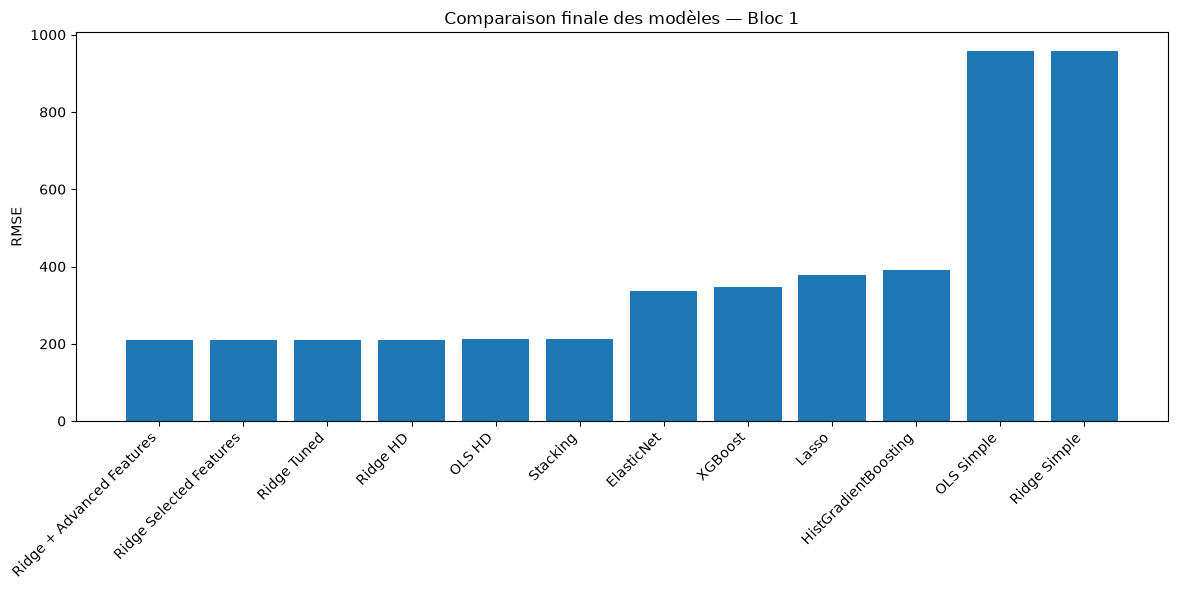

In [ ]:
results_plot = results_block1[
    results_block1["Model"] != "PCA + OLS"
]

plt.figure(figsize=(12, 6))

plt.bar(
    results_plot["Model"],
    results_plot["RMSE"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("RMSE")

plt.title(
    "Comparaison finale des modèles — Bloc 1"
)

plt.tight_layout()

plt.show()

Le premier résultat important est l’écart très important entre les modèles simples et les modèles haute dimension. L’OLS simple obtient un RMSE de validation d’environ 958 MW, tandis que l’OLS haute dimension descend à environ 211 MW. Cela montre que l’enrichissement des variables temporelles constitue l’amélioration la plus importante du Bloc 1.

Ridge obtient des performances légèrement supérieures à OLS lorsque le nombre de variables augmente et que les prédicteurs deviennent fortement corrélés. La régularisation L2 permet de stabiliser les coefficients sans supprimer les variables.

Lasso et Elastic Net sont moins performants, ce qui suggère que le problème n’est pas fortement sparse et qu’un grand nombre de variables contribuent simultanément à la prédiction.

PCA réduit fortement la dimension, mais dégrade considérablement les performances. Maximiser la variance expliquée de X ne garantit donc pas de préserver l’information la plus pertinente pour prédire la consommation électrique.

Les méthodes d’ensemble et le stacking n’apportent pas d’amélioration significative, principalement parce que les meilleurs modèles linéaires produisent des prédictions très similaires.

Les modèles non linéaires testés, notamment HistGradientBoosting et XGBoost, restent nettement moins performants que Ridge et OLS sur ce problème.

Enfin, le feature engineering avancé améliore encore légèrement les performances. Le meilleur résultat du Bloc 1 est obtenu par Ridge avec les nouvelles variables de différences, tendances locales et écarts aux moyennes récentes.

Le meilleur modèle retenu est Ridge avec feature engineering avancé, avec :

$$ RMSE ~ 210.89 $$ $$ MAE ~ 152.82 $$

Ce résultat confirme que, sur ce problème, l’amélioration de la représentation des données apporte davantage que le tuning très fin des hyperparamètres ou l’utilisation de modèles plus complexes.

Conclusion : Le Bloc 1 montre que la performance dépend avant tout de la qualité des variables construites. Le passage d’un modèle simple à un modèle haute dimension permet de réduire très fortement l’erreur de prédiction. Ridge s’avère particulièrement adapté en présence de nombreuses variables corrélées, tandis que Lasso et Elastic Net sont moins adaptés à ce problème peu sparse. PCA supprime une partie de l’information prédictive, et les modèles non linéaires testés ne dépassent pas les modèles linéaires. Les méthodes d’ensemble apportent également peu de gain en raison de la forte similarité entre les meilleurs prédicteurs. Le meilleur résultat final est obtenu avec Ridge associé à un feature engineering temporel avancé, avec un RMSE d’environ 210.89 MW.

## 21. Synthèse théorique et améliorations guidées par la théorie

L’objectif de cette partie est d’utiliser les notions théoriques vues dans le Bloc 1 pour analyser le comportement des modèles, comprendre leurs limites et proposer des améliorations guidées par la théorie.

Pour chaque notion, on relie :

1. la théorie,
2. ce qu’on observe dans le projet,
3. les conséquences pratiques,
4. les améliorations possibles.

### 21.1 Multicolinéarité, conditionnement et Ridge

Lorsque plusieurs variables explicatives sont fortement corrélées, certaines directions de la matrice \(X\) deviennent presque redondantes.

Cela se traduit par de petites valeurs singulières et donc par un mauvais conditionnement de la matrice.

On peut résumer la chaîne suivante :

$$
\text{fortes corrélations}
\Rightarrow
\text{petites valeurs singulières}
\Rightarrow
\text{mauvais conditionnement}
\Rightarrow
\text{coefficients OLS instables}
$$

Ridge corrige partiellement ce problème en remplaçant :

$$
X^T X
$$

par :

$$
X^T X + \lambda I
$$

Dans notre projet, les nombreux lags sont fortement corrélés, ce qui explique pourquoi Ridge est particulièrement adapté.

L’objectif de cette section est donc de mesurer le conditionnement de la matrice de features et d’analyser son spectre de valeurs singulières.

#### 21.1.1 Valeurs singulières et nombre de condition

La décomposition en valeurs singulières de $X$ s’écrit :

$$
X = U \Sigma V^T
$$

La matrice $\Sigma$ contient les valeurs singulières :

$$
\sigma_1 \geq \sigma_2 \geq ... \geq \sigma_p \geq 0
$$

La plus grande valeur singulière est notée :

$$
\sigma_{\max}
$$

et la plus petite :

$$
\sigma_{\min}
$$

Intuitivement :

- $\sigma_{\max}$ représente la direction dans laquelle les données présentent le plus de variation,
- $\sigma_{\min}$ représente la direction dans laquelle les données présentent le moins de variation.

Si $\sigma_{\min}$ est très proche de zéro, cela signifie qu’une direction de $X$ est presque redondante.

Le nombre de condition est défini par :

$$
\kappa(X)
=
\frac{\sigma_{\max}}{\sigma_{\min}}
$$

Si $\sigma_{\min}$ devient très petite, alors $\kappa(X)$ devient très grand.

Cela indique que la matrice est mal conditionnée.

#### 21.1.2 Calcul du conditionnement

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import joblib

condition_path = os.path.join(
    models_folder,
    "condition_analysis.joblib"
)

if os.path.exists(condition_path):

    condition_results = joblib.load(
        condition_path
    )

    singular_values = condition_results[
        "singular_values"
    ]

    condition_number = condition_results[
        "condition_number"
    ]

    print(
        "Analyse du conditionnement chargée"
    )

else:

    scaler_condition = StandardScaler()

    X_train_scaled_condition = (
        scaler_condition.fit_transform(
            X_train_adv
        )
    )

    singular_values = np.linalg.svd(
        X_train_scaled_condition,
        compute_uv=False
    )

    condition_number = (
        singular_values.max()
        / singular_values.min()
    )

    condition_results = {
        "singular_values": singular_values,
        "condition_number": condition_number
    }

    joblib.dump(
        condition_results,
        condition_path
    )

    print(
        "Analyse calculée et sauvegardée"
    )

Analyse du conditionnement chargée


In [ ]:
print(
    "Nombre de condition :",
    condition_number
)

print(
    "Sigma max :",
    singular_values.max()
)

print(
    "Sigma min :",
    singular_values.min()
)

Nombre de condition : 9.285160182402624e+16
Sigma max : 7378.095143206936
Sigma min : 7.946115089312098e-14


In [ ]:
print(
    "Nombre de valeurs singulières :",
    len(singular_values)
)

Nombre de valeurs singulières : 372


#### 21.1.3 Spectre des valeurs singulières

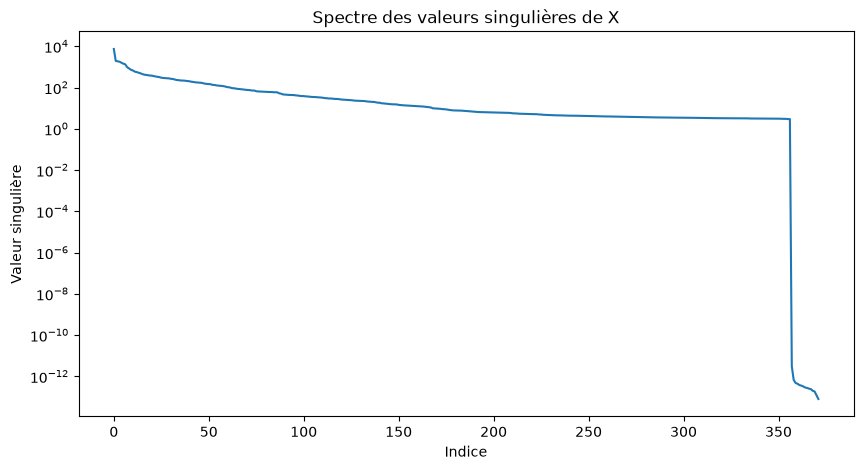

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    singular_values
)

plt.yscale("log")

plt.xlabel(
    "Indice"
)

plt.ylabel(
    "Valeur singulière"
)

plt.title(
    "Spectre des valeurs singulières de X"
)

plt.show()

#### 21.1.4 Suppression des directions numériquement redondantes

Le très grand nombre de condition montre que certaines directions de la matrice sont pratiquement nulles.

Contrairement à la PCA utilisée précédemment, l'objectif n'est pas ici de conserver seulement 95 % de la variance.

On cherche uniquement à supprimer les directions numériquement redondantes, c'est-à-dire celles dont les valeurs singulières sont pratiquement nulles.

Cette approche doit permettre de mieux conditionner le problème sans supprimer une quantité importante d'information prédictive.

In [ ]:
eps = np.finfo(float).eps

tol = (
    eps
    * max(X_train_adv.shape)
    * singular_values.max()
)

numerical_rank = np.sum(
    singular_values > tol
)

n_removed = (
    len(singular_values)
    - numerical_rank
)

print("Tolérance numérique :", tol)
print("Nombre de features :", len(singular_values))
print("Rang numérique :", numerical_rank)
print("Directions redondantes :", n_removed)

Tolérance numérique : 3.441178197573207e-07
Nombre de features : 372
Rang numérique : 357
Directions redondantes : 15


#### 21.1.5 Réduction minimale basée sur le rang numérique

#### Interprétation du rang numérique

La matrice contient 372 variables, mais son rang numérique est seulement de 357.

Cela signifie qu'environ 15 directions sont numériquement redondantes.

L'objectif est donc de supprimer uniquement ces directions presque nulles, sans effectuer une réduction de dimension agressive.

On teste ainsi une version de Ridge basée sur 357 composantes afin de vérifier si l'amélioration du conditionnement permet d'améliorer les performances prédictives.

In [ ]:
ridge_rank_reduced = Pipeline([
    ("scaler", StandardScaler()),

    ("pca", PCA(
        n_components=357
    )),

    ("model", Ridge(
        alpha=0.3994880193954167
    ))
])

In [ ]:
rank_reduced_path = os.path.join(
    models_folder,
    "ridge_rank_reduced_357.joblib"
)

if os.path.exists(rank_reduced_path):

    ridge_rank_reduced = joblib.load(
        rank_reduced_path
    )

    print("Ridge rank reduced chargé")

else:

    ridge_rank_reduced.fit(
        X_train_adv,
        y_train_adv
    )

    joblib.dump(
        ridge_rank_reduced,
        rank_reduced_path
    )

    print(
        "Ridge rank reduced entraîné et sauvegardé"
    )

Ridge rank reduced chargé


In [ ]:
pred_rank_reduced = ridge_rank_reduced.predict(
    X_val_adv
)

rmse_rank_reduced = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_rank_reduced
    )
)

mae_rank_reduced = mean_absolute_error(
    y_val_adv,
    pred_rank_reduced
)

print(
    "Ridge Rank Reduced RMSE :",
    rmse_rank_reduced
)

print(
    "Ridge Rank Reduced MAE :",
    mae_rank_reduced
)

Ridge Rank Reduced RMSE : 210.89360489048676
Ridge Rank Reduced MAE : 152.81600755860256


#### Conclusion de la réduction basée sur le rang numérique

La matrice contient 372 variables mais seulement 357 directions numériquement indépendantes.

Une réduction minimale de dimension a donc été testée en supprimant uniquement les 15 directions pratiquement redondantes.

Les performances obtenues sont :

$$
RMSE \approx 210.894
$$

$$
MAE \approx 152.816
$$

Ces résultats sont pratiquement identiques à ceux du modèle Ridge complet.

Cela montre que les directions redondantes n'augmentaient pas réellement l'erreur prédictive.

Ridge gérait déjà efficacement cette multicolinéarité grâce à la régularisation L2.

La réduction basée sur le rang numérique améliore donc principalement la représentation numérique du problème, mais pas les performances de prédiction.

### 21.2 Biais-variance et stabilité des coefficients

En présence de multicolinéarité, OLS peut produire des coefficients très variables lorsque les données changent légèrement.

Ridge introduit volontairement du biais afin de réduire cette variance.

On cherche donc à vérifier expérimentalement si :

$$
Var(\hat{\beta}_{Ridge})
<
Var(\hat{\beta}_{OLS})
$$

Pour cela, on va entraîner OLS et Ridge sur plusieurs folds temporels et comparer la variabilité de leurs coefficients.

#### 21.2.1 Calcul des coefficients sur plusieurs folds temporels

In [ ]:
coef_stability_path = os.path.join(
    models_folder,
    "coef_stability_ols_ridge.joblib"
)

if os.path.exists(coef_stability_path):

    coef_stability = joblib.load(
        coef_stability_path
    )

    ols_coefs = coef_stability["ols_coefs"]
    ridge_coefs = coef_stability["ridge_coefs"]

    print("Analyse de stabilité chargée")

else:

    tscv_stability = TimeSeriesSplit(
        n_splits=5
    )

    ols_coefs = []
    ridge_coefs = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv_stability.split(X_train_adv),
        start=1
    ):

        print(f"Fold {fold}")

        X_fold_train = X_train_adv.iloc[
            train_idx
        ]

        y_fold_train = y_train_adv.iloc[
            train_idx
        ]

        scaler_fold = StandardScaler()

        X_fold_scaled = scaler_fold.fit_transform(
            X_fold_train
        )

        ols_fold = LinearRegression()

        ols_fold.fit(
            X_fold_scaled,
            y_fold_train
        )

        ridge_fold = Ridge(
            alpha=0.3994880193954167
        )

        ridge_fold.fit(
            X_fold_scaled,
            y_fold_train
        )

        ols_coefs.append(
            ols_fold.coef_
        )

        ridge_coefs.append(
            ridge_fold.coef_
        )

    ols_coefs = np.array(
        ols_coefs
    )

    ridge_coefs = np.array(
        ridge_coefs
    )

    coef_stability = {
        "ols_coefs": ols_coefs,
        "ridge_coefs": ridge_coefs
    }

    joblib.dump(
        coef_stability,
        coef_stability_path
    )

    print(
        "Analyse calculée et sauvegardée"
    )

Analyse de stabilité chargée


#### 21.2.2 Mesure de la variabilité des coefficients

In [ ]:
ols_coef_std = np.std(
    ols_coefs,
    axis=0
)

ridge_coef_std = np.std(
    ridge_coefs,
    axis=0
)

In [ ]:
stability_df = pd.DataFrame({
    "feature": features_hd_advanced,
    "OLS_std": ols_coef_std,
    "Ridge_std": ridge_coef_std
})

stability_df["ratio_OLS_Ridge"] = (
    stability_df["OLS_std"]
    /
    (
        stability_df["Ridge_std"]
        + 1e-12
    )
)

In [ ]:
stability_df = stability_df.sort_values(
    "ratio_OLS_Ridge",
    ascending=False
)

stability_df.head(20)

,feature,OLS_std,Ridge_std,ratio_OLS_Ridge
239,lag_240,55.430254,13.784906,4.021083
50,lag_51,62.807433,25.740608,2.440014
106,lag_107,35.061391,14.714413,2.382792
247,lag_248,25.688843,11.929413,2.153404
107,lag_108,33.983851,15.846441,2.144573
287,lag_288,62.677450,29.721604,2.108818
17,lag_18,61.025259,29.965906,2.036490
94,lag_95,60.850490,30.011425,2.027578
122,lag_123,36.245269,19.432564,1.865182
49,lag_50,141.062275,76.387979,1.846655


In [ ]:
mean_ols_std = ols_coef_std.mean()
mean_ridge_std = ridge_coef_std.mean()

median_ols_std = np.median(
    ols_coef_std
)

median_ridge_std = np.median(
    ridge_coef_std
)

print(
    "Écart-type moyen OLS :",
    mean_ols_std
)

print(
    "Écart-type moyen Ridge :",
    mean_ridge_std
)

print(
    "Écart-type médian OLS :",
    median_ols_std
)

print(
    "Écart-type médian Ridge :",
    median_ridge_std
)

Écart-type moyen OLS : 52.510528719407866
Écart-type moyen Ridge : 45.97186568336971
Écart-type médian OLS : 48.47844804138991
Écart-type médian Ridge : 41.825840633638165


#### 21.2.3 Comparaison graphique de la stabilité

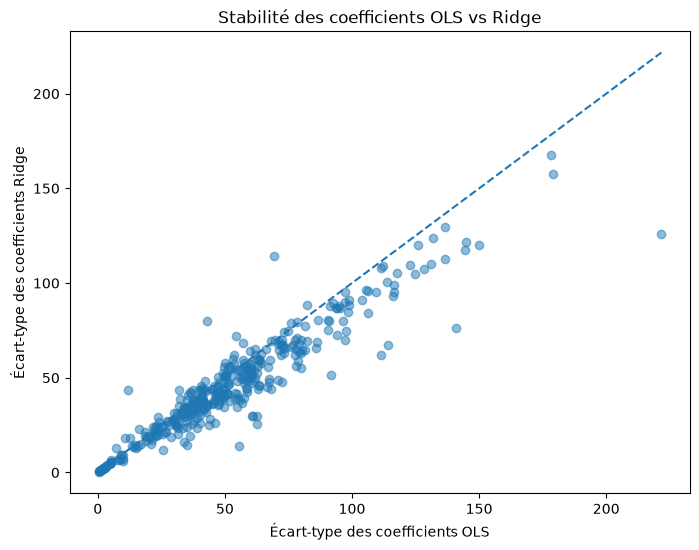

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ols_coef_std,
    ridge_coef_std,
    alpha=0.5
)

max_std = max(
    ols_coef_std.max(),
    ridge_coef_std.max()
)

plt.plot(
    [0, max_std],
    [0, max_std],
    linestyle="--"
)

plt.xlabel(
    "Écart-type des coefficients OLS"
)

plt.ylabel(
    "Écart-type des coefficients Ridge"
)

plt.title(
    "Stabilité des coefficients OLS vs Ridge"
)

plt.show()

#### 21.2.4 Sélection des variables basée sur la stabilité

Une variable dont le coefficient change fortement entre les folds temporels peut être difficile à estimer de manière robuste.

Cependant, supprimer simplement les coefficients ayant le plus grand écart-type serait trompeur : un coefficient important peut naturellement avoir une variation absolue plus élevée.

On utilise donc une mesure relative d'instabilité :

$$
S_j =
\frac{\operatorname{std}(\hat{\beta}_j)}
{\operatorname{mean}(|\hat{\beta}_j|)+\varepsilon}
$$

Une grande valeur de $S_j$ indique que le coefficient varie beaucoup par rapport à son amplitude habituelle.

L'objectif est de tester si la suppression d'une petite proportion des variables les plus instables améliore la généralisation de Ridge.

In [ ]:
ridge_coef_mean_abs = np.mean(
    np.abs(ridge_coefs),
    axis=0
)

ridge_coef_std = np.std(
    ridge_coefs,
    axis=0
)

stability_score = (
    ridge_coef_std
    /
    (ridge_coef_mean_abs + 1e-12)
)

stability_selection_df = pd.DataFrame({
    "feature": features_hd_advanced,
    "mean_abs_coef": ridge_coef_mean_abs,
    "std_coef": ridge_coef_std,
    "instability_score": stability_score
})

stability_selection_df = (
    stability_selection_df
    .sort_values(
        "instability_score",
        ascending=False
    )
)

stability_selection_df.head(20)

,feature,mean_abs_coef,std_coef,instability_score
100,lag_101,24.785440,38.399391,1.549272
55,lag_56,44.628492,65.002646,1.456528
78,lag_79,114.409362,157.718784,1.378548
9,lag_10,45.904238,62.661779,1.365054
43,lag_44,33.709633,45.917968,1.362162
235,lag_236,79.275869,107.261730,1.353019
196,lag_197,71.181498,95.099389,1.336013
342,lag_17568,3.556110,4.726044,1.328993
206,lag_207,36.798743,48.433301,1.316167
172,lag_173,27.361936,35.472109,1.296403


In [ ]:
sign_consistency = []

for j in range(ridge_coefs.shape[1]):

    coef_j = ridge_coefs[:, j]

    positive_ratio = np.mean(
        coef_j > 0
    )

    negative_ratio = np.mean(
        coef_j < 0
    )

    sign_consistency.append(
        max(
            positive_ratio,
            negative_ratio
        )
    )

stability_selection_df_sign = pd.DataFrame({
    "feature": features_hd_advanced,
    "sign_consistency": sign_consistency
})

stability_selection_df = (
    stability_selection_df
    .merge(
        stability_selection_df_sign,
        on="feature"
    )
)

stability_selection_df.head(20)

,feature,mean_abs_coef,std_coef,instability_score,sign_consistency
0,lag_101,24.785440,38.399391,1.549272,0.8
1,lag_56,44.628492,65.002646,1.456528,0.6
2,lag_79,114.409362,157.718784,1.378548,0.6
3,lag_10,45.904238,62.661779,1.365054,0.6
4,lag_44,33.709633,45.917968,1.362162,0.8
5,lag_236,79.275869,107.261730,1.353019,0.6
6,lag_197,71.181498,95.099389,1.336013,0.6
7,lag_17568,3.556110,4.726044,1.328993,0.8
8,lag_207,36.798743,48.433301,1.316167,0.6
9,lag_173,27.361936,35.472109,1.296403,0.6


#### 21.2.5 Validation temporelle de la sélection par stabilité

La proportion de variables supprimées ne doit pas être choisie directement à partir de l'année 2025.

On utilise donc une validation croisée temporelle uniquement sur la période d'entraînement.

Les proportions testées sont :

- 0 %,
- 5 %,
- 10 %,
- 20 %.

La configuration obtenant le meilleur RMSE moyen en validation temporelle sera ensuite évaluée une seule fois sur 2025.

In [ ]:
stability_cv_path = os.path.join(
    models_folder,
    "stability_feature_selection_cv.joblib"
)

if os.path.exists(stability_cv_path):

    stability_cv_results = joblib.load(
        stability_cv_path
    )

    print(
        "Sélection par stabilité chargée"
    )

else:

    removal_rates = [
        0.00,
        0.05,
        0.10,
        0.20
    ]

    stability_cv_results = []

    tscv_feature_selection = TimeSeriesSplit(
        n_splits=3
    )

    ranked_features = (
        stability_selection_df[
            "feature"
        ].tolist()
    )

    for removal_rate in removal_rates:

        n_remove = int(
            len(features_hd_advanced)
            * removal_rate
        )

        features_to_remove = set(
            ranked_features[:n_remove]
        )

        selected_features_stability = [
            feature
            for feature in features_hd_advanced
            if feature not in features_to_remove
        ]

        fold_rmse = []

        for train_idx, val_idx in (
            tscv_feature_selection.split(
                X_train_adv
            )
        ):

            X_fold_train = (
                X_train_adv
                .iloc[train_idx][
                    selected_features_stability
                ]
            )

            y_fold_train = (
                y_train_adv.iloc[train_idx]
            )

            X_fold_val = (
                X_train_adv
                .iloc[val_idx][
                    selected_features_stability
                ]
            )

            y_fold_val = (
                y_train_adv.iloc[val_idx]
            )

            model_stability = Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    Ridge(
                        alpha=0.3994880193954167
                    )
                )
            ])

            model_stability.fit(
                X_fold_train,
                y_fold_train
            )

            pred_fold = (
                model_stability.predict(
                    X_fold_val
                )
            )

            rmse_fold = np.sqrt(
                mean_squared_error(
                    y_fold_val,
                    pred_fold
                )
            )

            fold_rmse.append(
                rmse_fold
            )

        stability_cv_results.append({
            "removal_rate": removal_rate,
            "n_removed": n_remove,
            "n_features": len(
                selected_features_stability
            ),
            "cv_rmse": np.mean(
                fold_rmse
            )
        })

    joblib.dump(
        stability_cv_results,
        stability_cv_path
    )

    print(
        "Sélection calculée et sauvegardée"
    )

Sélection par stabilité chargée


In [ ]:
stability_cv_df = pd.DataFrame(
    stability_cv_results
).sort_values(
    "cv_rmse"
)

stability_cv_df

,removal_rate,n_removed,n_features,cv_rmse
3,0.20,74,298,254.295314
2,0.10,37,335,254.320679
1,0.05,18,354,254.369643
0,0.00,0,372,254.413922


In [ ]:
best_stability_row = (
    stability_cv_df.iloc[0]
)

best_removal_rate = (
    best_stability_row[
        "removal_rate"
    ]
)

best_n_remove = int(
    best_stability_row[
        "n_removed"
    ]
)

print(
    "Meilleur taux de suppression :",
    best_removal_rate
)

print(
    "Nombre de variables supprimées :",
    best_n_remove
)

print(
    "Meilleur CV RMSE :",
    best_stability_row["cv_rmse"]
)

Meilleur taux de suppression : 0.2
Nombre de variables supprimées : 74
Meilleur CV RMSE : 254.29531395870063


In [ ]:
ranked_features = (
    stability_selection_df[
        "feature"
    ].tolist()
)

features_removed_stability = set(
    ranked_features[
        :best_n_remove
    ]
)

features_stable = [
    feature
    for feature in features_hd_advanced
    if feature not in features_removed_stability
]

print(
    "Nombre final de features :",
    len(features_stable)
)

Nombre final de features : 298


#### 21.2.6 Évaluation du modèle avec variables stables

In [ ]:
ridge_stable = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        Ridge(
            alpha=0.3994880193954167
        )
    )
])

In [ ]:
ridge_stable_path = os.path.join(
    models_folder,
    "ridge_stability_selected.joblib"
)

if os.path.exists(ridge_stable_path):

    ridge_stable = joblib.load(
        ridge_stable_path
    )

    print(
        "Ridge stability selected chargé"
    )

else:

    ridge_stable.fit(
        X_train_adv[
            features_stable
        ],
        y_train_adv
    )

    joblib.dump(
        ridge_stable,
        ridge_stable_path
    )

    print(
        "Ridge stability selected entraîné et sauvegardé"
    )

Ridge stability selected chargé


In [ ]:
pred_ridge_stable = (
    ridge_stable.predict(
        X_val_adv[
            features_stable
        ]
    )
)

rmse_ridge_stable = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_ridge_stable
    )
)

mae_ridge_stable = (
    mean_absolute_error(
        y_val_adv,
        pred_ridge_stable
    )
)

print(
    "Ridge Stable RMSE :",
    rmse_ridge_stable
)

print(
    "Ridge Stable MAE :",
    mae_ridge_stable
)

Ridge Stable RMSE : 211.04851323625903
Ridge Stable MAE : 152.95524507355003


#### Choix entre performance maximale et parcimonie

Le modèle complet utilisant 372 features obtient :

$$
RMSE \approx 210.89
$$

et

$$
MAE \approx 152.82
$$

Le modèle sélectionné sur la stabilité conserve seulement 298 features et obtient :

$$
RMSE \approx 211.05
$$

et

$$
MAE \approx 152.96
$$

La perte de performance est donc très faible malgré la suppression d'environ 20 % des variables.

Ce résultat suggère qu'une partie des features supprimées apporte peu d'information supplémentaire et peut éventuellement capturer des structures instables ou du bruit.

Dans une logique de parcimonie, le modèle avec 298 features peut donc être préféré si l'on souhaite réduire la complexité tout en conservant des performances quasiment identiques.

### 21.3 Sparsité et Lasso### 21.3 Sparsité et Lasso

Un problème est dit sparse lorsqu'un petit nombre de variables suffit à expliquer l'essentiel du signal.

On note :

$$
s \ll p
$$

où $p$ est le nombre total de variables et $s$ le nombre de coefficients réellement utiles.

Lasso utilise une pénalisation L1 :

$$
\min_{\beta}
\left[
\|y-X\beta\|_2^2
+
\lambda\|\beta\|_1
\right]
$$

Cette pénalisation peut mettre certains coefficients exactement à zéro.

Si notre problème est réellement sparse, on devrait observer :

- peu de coefficients non nuls,
- une sélection relativement stable entre les périodes,
- des performances proches ou meilleures que Ridge avec beaucoup moins de variables.

L'objectif est donc de mesurer la sparsité et la stabilité de la sélection réalisée par Lasso.

#### 21.3.1 Nombre de variables sélectionnées par Lasso

In [ ]:
lasso_sparsity = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=1.2,
        max_iter=5000,
        tol=1e-3
    ))
])

In [ ]:
lasso_sparsity_path = os.path.join(
    models_folder,
    "lasso_sparsity_advanced.joblib"
)

if os.path.exists(lasso_sparsity_path):

    lasso_sparsity = joblib.load(
        lasso_sparsity_path
    )

    print("Lasso sparsity chargé")

else:

    lasso_sparsity.fit(
        X_train_adv,
        y_train_adv
    )

    joblib.dump(
        lasso_sparsity,
        lasso_sparsity_path
    )

    print(
        "Lasso sparsity entraîné et sauvegardé"
    )

Lasso sparsity chargé


In [ ]:
lasso_coef = (
    lasso_sparsity
    .named_steps["model"]
    .coef_
)

n_nonzero = np.sum(
    np.abs(lasso_coef) > 1e-8
)

n_total = len(lasso_coef)

sparsity_rate = (
    n_nonzero / n_total
)

print(
    "Nombre total de features :",
    n_total
)

print(
    "Coefficients non nuls :",
    n_nonzero
)

print(
    "Pourcentage sélectionné :",
    100 * sparsity_rate
)

Nombre total de features : 372
Coefficients non nuls : 244
Pourcentage sélectionné : 65.59139784946237


#### 21.3.2 Stabilité de la sélection Lasso dans le temps

In [ ]:
lasso_support_path = os.path.join(
    models_folder,
    "lasso_support_stability.joblib"
)

if os.path.exists(lasso_support_path):

    lasso_support_results = joblib.load(
        lasso_support_path
    )

    supports = lasso_support_results[
        "supports"
    ]

    print(
        "Supports Lasso chargés"
    )

else:

    tscv_lasso = TimeSeriesSplit(
        n_splits=3
    )

    supports = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv_lasso.split(X_train_adv),
        start=1
    ):

        print(f"Fold {fold}")

        X_fold_train = (
            X_train_adv.iloc[train_idx]
        )

        y_fold_train = (
            y_train_adv.iloc[train_idx]
        )

        model_fold = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(
                alpha=1.2,
                max_iter=3000,
                tol=1e-3
            ))
        ])

        model_fold.fit(
            X_fold_train,
            y_fold_train
        )

        coef_fold = (
            model_fold
            .named_steps["model"]
            .coef_
        )

        support_fold = set(
            np.array(
                features_hd_advanced
            )[
                np.abs(coef_fold) > 1e-8
            ]
        )

        supports.append(
            support_fold
        )

    lasso_support_results = {
        "supports": supports
    }

    joblib.dump(
        lasso_support_results,
        lasso_support_path
    )

    print(
        "Supports Lasso calculés et sauvegardés"
    )

Supports Lasso chargés


In [ ]:
jaccard_results = []

for i in range(len(supports)):

    for j in range(i + 1, len(supports)):

        intersection = len(
            supports[i] & supports[j]
        )

        union = len(
            supports[i] | supports[j]
        )

        jaccard = (
            intersection / union
        )

        jaccard_results.append(
            jaccard
        )

        print(
            f"Fold {i+1} vs Fold {j+1} :",
            jaccard
        )

print(
    "Jaccard moyen :",
    np.mean(jaccard_results)
)

Fold 1 vs Fold 2 : 0.9061371841155235
Fold 1 vs Fold 3 : 0.8844765342960289
Fold 2 vs Fold 3 : 0.8962962962962963
Jaccard moyen : 0.895636671569283


In [ ]:
for i, support in enumerate(
    supports,
    start=1
):

    print(
        f"Fold {i} :",
        len(support),
        "features sélectionnées"
    )

Fold 1 : 269 features sélectionnées
Fold 2 : 259 features sélectionnées
Fold 3 : 253 features sélectionnées


#### Conclusion sur la sparsité

Lasso conserve 244 variables sur 372 sur l'ensemble de l'entraînement :

$$
\frac{244}{372} \approx 65.6\%
$$

Environ 34 % des variables sont donc éliminées.

Cette sélection ne correspond pas à une forte sparsité au sens :

$$
s \ll p
$$

car une majorité des variables reste nécessaire.

Cependant, la sélection réalisée par Lasso est relativement stable dans le temps.

Les indices de Jaccard entre les supports des différents folds sont proches de 0.9 :

$$
J_{moyen} \approx 0.896
$$

Cela montre qu'une grande partie des variables sélectionnées est commune aux différentes périodes.

Le problème n'est donc pas fortement sparse, mais il existe néanmoins un sous-ensemble relativement stable de variables importantes.

#### 21.3.3 Sélection Lasso suivie de Ridge

Lasso est moins performant que Ridge comme modèle prédictif, mais sa sélection de variables est relativement stable.

On peut donc utiliser Lasso uniquement comme méthode de sélection puis entraîner Ridge sur les variables retenues.

Cette approche combine les avantages des deux pénalisations :

$$
L1 \rightarrow \text{sélection de variables}
$$

$$
L2 \rightarrow \text{stabilité des coefficients}
$$

L'objectif est d'obtenir un modèle plus parcimonieux tout en conservant les bonnes performances prédictives de Ridge.

In [ ]:
lasso_selected_features = list(
    np.array(features_hd_advanced)[
        np.abs(lasso_coef) > 1e-8
    ]
)

print(
    "Nombre de features retenues :",
    len(lasso_selected_features)
)

Nombre de features retenues : 244


In [ ]:
ridge_lasso_selection = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(
        alpha=0.3994880193954167
    ))
])

In [ ]:
ridge_lasso_path = os.path.join(
    models_folder,
    "ridge_after_lasso_selection.joblib"
)

if os.path.exists(ridge_lasso_path):

    ridge_lasso_selection = joblib.load(
        ridge_lasso_path
    )

    print("Ridge après sélection Lasso chargé")

else:

    ridge_lasso_selection.fit(
        X_train_adv[
            lasso_selected_features
        ],
        y_train_adv
    )

    joblib.dump(
        ridge_lasso_selection,
        ridge_lasso_path
    )

    print(
        "Ridge après sélection Lasso entraîné et sauvegardé"
    )

Ridge après sélection Lasso chargé


In [ ]:
pred_ridge_lasso = (
    ridge_lasso_selection.predict(
        X_val_adv[
            lasso_selected_features
        ]
    )
)

rmse_ridge_lasso = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_ridge_lasso
    )
)

mae_ridge_lasso = mean_absolute_error(
    y_val_adv,
    pred_ridge_lasso
)

print(
    "Ridge après Lasso RMSE :",
    rmse_ridge_lasso
)

print(
    "Ridge après Lasso MAE :",
    mae_ridge_lasso
)

Ridge après Lasso RMSE : 212.03683028298272
Ridge après Lasso MAE : 153.38230233680625


In [ ]:
comparison_parsimony = pd.DataFrame({
    "Model": [
        "Ridge complet",
        "Ridge stabilité",
        "Lasso → Ridge"
    ],
    "Features": [
        372,
        298,
        244
    ],
    "RMSE": [
        210.893604890517,
        211.04851323625903,
        212.03683028298272
    ],
    "MAE": [
        152.81600755863204,
        152.95524507355003,
        153.38230233680625
    ]
})

comparison_parsimony

,Model,Features,RMSE,MAE
0,Ridge complet,372,210.893605,152.816008
1,Ridge stabilité,298,211.048513,152.955245
2,Lasso → Ridge,244,212.036830,153.382302


#### Conclusion de la sélection Lasso suivie de Ridge

La sélection réalisée par Lasso permet de réduire le nombre de variables de 372 à 244, soit une diminution d'environ 34 %.

Le modèle Ridge entraîné uniquement sur ces variables obtient :

$$
RMSE \approx 212.04
$$

et :

$$
MAE \approx 153.38
$$

Les performances se dégradent légèrement par rapport au modèle Ridge complet :

$$
RMSE \approx 210.89
$$

mais la réduction du nombre de variables est importante.

Cette version peut donc présenter plusieurs avantages :

- temps d'entraînement plus faible,
- modèle plus parcimonieux,
- réduction de la redondance,
- potentiellement meilleure stabilité,
- interprétation plus simple.

Il existe donc un compromis entre performance prédictive maximale et simplicité du modèle.

Le modèle complet reste le meilleur en termes de RMSE, tandis que la version Lasso puis Ridge constitue une alternative plus compacte avec une perte de performance relativement faible.

#### 21.3.4 Compromis performance, complexité et temps de calcul

La réduction du nombre de variables peut avoir plusieurs avantages :

- diminuer le temps d'entraînement,
- réduire la mémoire utilisée,
- simplifier l'interprétation,
- limiter la redondance entre les variables.

Cependant, une réduction du nombre de variables n'implique pas automatiquement une meilleure stabilité.

On compare donc trois modèles Ridge utilisant respectivement :

- 372 variables : modèle complet,
- 298 variables : sélection par stabilité,
- 244 variables : sélection Lasso.

Tous les modèles utilisent le même hyperparamètre Ridge afin que la comparaison soit équitable.

In [ ]:
import time

timing_path = os.path.join(
    models_folder,
    "ridge_feature_timing.joblib"
)

if os.path.exists(timing_path):

    timing_results = joblib.load(
        timing_path
    )

    print("Résultats de temps chargés")

else:

    model_configs = {
        "Ridge complet": (
            X_train_adv,
            features_hd_advanced
        ),

        "Ridge stabilité": (
            X_train_adv,
            features_stable
        ),

        "Lasso → Ridge": (
            X_train_adv,
            lasso_selected_features
        )
    }

    timing_results = []

    for name, (X_data, features) in model_configs.items():

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(
                alpha=0.3994880193954167
            ))
        ])

        start = time.perf_counter()

        model.fit(
            X_data[features],
            y_train_adv
        )

        elapsed = (
            time.perf_counter()
            - start
        )

        timing_results.append({
            "Model": name,
            "Features": len(features),
            "Training_time_seconds": elapsed
        })

        print(
            name,
            ":",
            round(elapsed, 3),
            "secondes"
        )

    joblib.dump(
        timing_results,
        timing_path
    )

    print(
        "Résultats de temps sauvegardés"
    )

Résultats de temps chargés


In [ ]:
timing_df = pd.DataFrame(
    timing_results
)

timing_df

,Model,Features,Training_time_seconds
0,Ridge complet,372,4.879235
1,Ridge stabilité,298,2.839818
2,Lasso → Ridge,244,2.194390


In [ ]:
comparison_parsimony = (
    comparison_parsimony
    .merge(
        timing_df,
        on=[
            "Model",
            "Features"
        ]
    )
)

comparison_parsimony

,Model,Features,RMSE,MAE,Training_time_seconds
0,Ridge complet,372,210.893605,152.816008,4.879235
1,Ridge stabilité,298,211.048513,152.955245,2.839818
2,Lasso → Ridge,244,212.036830,153.382302,2.194390


In [ ]:
comparison_parsimony[
    "Feature_reduction_%"
] = (
    1
    -
    comparison_parsimony["Features"]
    / 372
) * 100

comparison_parsimony

,Model,Features,RMSE,MAE,Training_time_seconds,Feature_reduction_%
0,Ridge complet,372,210.893605,152.816008,4.879235,0.000000
1,Ridge stabilité,298,211.048513,152.955245,2.839818,19.892473
2,Lasso → Ridge,244,212.036830,153.382302,2.194390,34.408602


#### Conclusion sur le compromis performance-complexité

Le modèle Ridge complet obtient la meilleure performance prédictive :

$$
RMSE \approx 210.89
$$

avec 372 variables et un temps d'entraînement d'environ :

$$
4.88 \text{ secondes}
$$

La sélection par stabilité conserve 298 variables, soit environ 20 % de variables en moins, pour un RMSE de :

$$
211.05
$$

et un temps d'entraînement d'environ :

$$
2.84 \text{ secondes}
$$

La perte de performance est donc très faible, tandis que le temps d'entraînement diminue fortement.

La stratégie Lasso puis Ridge réduit encore davantage la dimension, avec 244 variables, soit environ 34 % de variables en moins.

Elle obtient :

$$
RMSE \approx 212.04
$$

avec un temps d'entraînement d'environ :

$$
2.19 \text{ secondes}
$$

Ces résultats montrent qu'il existe un compromis clair entre précision, complexité et coût de calcul.

Le modèle complet reste préférable si l'objectif principal est la performance maximale.

Le modèle basé sur la stabilité constitue cependant un excellent compromis : il conserve presque toute la performance tout en réduisant sensiblement le nombre de variables et le temps d'entraînement.

### 21.4 SVD, PCA et information prédictive

La PCA conserve les directions de plus grande variance de la matrice $X$.

Cependant, elle ne tient pas compte de la variable cible $y$.

Ainsi :

$$
\text{forte variance dans } X
\neq
\text{forte utilité pour prédire } y
$$

Dans notre projet, environ 95 % de la variance de $X$ est expliquée avec seulement 11 composantes principales, mais les performances prédictives se dégradent fortement.

L'objectif de cette section est donc d'étudier la relation entre variance expliquée et information prédictive.

#### 21.4.1 Variance expliquée cumulée

In [ ]:
pca_analysis_path = os.path.join(
    models_folder,
    "pca_variance_analysis.joblib"
)

if os.path.exists(pca_analysis_path):

    pca_analysis = joblib.load(
        pca_analysis_path
    )

    explained_variance_ratio = pca_analysis[
        "explained_variance_ratio"
    ]

    cumulative_variance = pca_analysis[
        "cumulative_variance"
    ]

    print("Analyse PCA chargée")

else:

    scaler_pca_analysis = StandardScaler()

    X_train_scaled_pca = (
        scaler_pca_analysis.fit_transform(
            X_train_adv
        )
    )

    pca_full = PCA()

    pca_full.fit(
        X_train_scaled_pca
    )

    explained_variance_ratio = (
        pca_full.explained_variance_ratio_
    )

    cumulative_variance = np.cumsum(
        explained_variance_ratio
    )

    pca_analysis = {
        "explained_variance_ratio":
            explained_variance_ratio,
        "cumulative_variance":
            cumulative_variance
    }

    joblib.dump(
        pca_analysis,
        pca_analysis_path
    )

    print(
        "Analyse PCA calculée et sauvegardée"
    )

Analyse PCA chargée


In [ ]:
for threshold in [
    0.90,
    0.95,
    0.99,
    0.999
]:

    n_components = (
        np.argmax(
            cumulative_variance >= threshold
        )
        + 1
    )

    print(
        f"{threshold*100:.1f}% de variance :",
        n_components,
        "composantes"
    )

90.0% de variance : 7 composantes
95.0% de variance : 13 composantes
99.0% de variance : 38 composantes
99.9% de variance : 84 composantes


#### 21.4.2 Courbe de variance expliquée

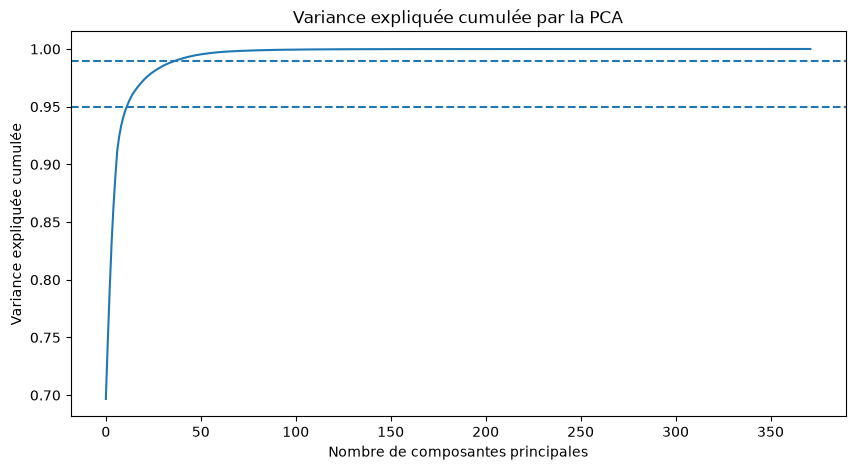

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    cumulative_variance
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.axhline(
    0.99,
    linestyle="--"
)

plt.xlabel(
    "Nombre de composantes principales"
)

plt.ylabel(
    "Variance expliquée cumulée"
)

plt.title(
    "Variance expliquée cumulée par la PCA"
)

plt.show()

#### 21.4.3 Performance prédictive selon le nombre de composantes

Pour déterminer si des directions de faible variance contiennent une information prédictive utile, on compare plusieurs niveaux de réduction de dimension.

On teste différentes proportions de variance expliquée, puis on entraîne Ridge sur les composantes principales.

Si les performances s'améliorent fortement lorsque l'on conserve presque toutes les composantes, cela indiquera que certaines directions de faible variance sont importantes pour la prédiction.

In [ ]:
pca_thresholds = [
    0.90,
    0.95,
    0.99,
    0.999,
    0.9999
]

In [ ]:
pca_prediction_path = os.path.join(
    models_folder,
    "pca_prediction_thresholds.joblib"
)

if os.path.exists(pca_prediction_path):

    pca_prediction_results = joblib.load(
        pca_prediction_path
    )

    print(
        "Résultats PCA prédictifs chargés"
    )

else:

    pca_prediction_results = []

    for threshold in pca_thresholds:

        print(
            "Test variance :",
            threshold
        )

        model_pca_ridge = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "pca",
                PCA(
                    n_components=threshold
                )
            ),
            (
                "model",
                Ridge(
                    alpha=0.3994880193954167
                )
            )
        ])

        model_pca_ridge.fit(
            X_train_adv,
            y_train_adv
        )

        pred_pca_ridge = (
            model_pca_ridge.predict(
                X_val_adv
            )
        )

        rmse_pca = np.sqrt(
            mean_squared_error(
                y_val_adv,
                pred_pca_ridge
            )
        )

        mae_pca = mean_absolute_error(
            y_val_adv,
            pred_pca_ridge
        )

        n_comp = (
            model_pca_ridge
            .named_steps["pca"]
            .n_components_
        )

        pca_prediction_results.append({
            "variance_threshold": threshold,
            "n_components": n_comp,
            "RMSE": rmse_pca,
            "MAE": mae_pca
        })

    joblib.dump(
        pca_prediction_results,
        pca_prediction_path
    )

    print(
        "Résultats PCA sauvegardés"
    )

Résultats PCA prédictifs chargés


In [ ]:
pca_prediction_df = pd.DataFrame(
    pca_prediction_results
)

pca_prediction_df

,variance_threshold,n_components,RMSE,MAE
0,0.9000,7,2455.460732,1874.816033
1,0.9500,13,918.036349,711.758128
2,0.9900,38,585.340195,460.752945
3,0.9990,84,466.558072,365.329648
4,0.9999,149,275.077330,209.462051


#### Conclusion sur PCA et l'information prédictive

Les résultats montrent que les performances s'améliorent fortement lorsque davantage de composantes principales sont conservées.

Cependant, même avec 99.99 % de variance expliquée et 149 composantes, le modèle reste nettement moins performant que Ridge entraîné sur les features originales.

Cela montre que les directions de faible variance contiennent une information importante pour prédire la consommation électrique.

La PCA est une méthode non supervisée : elle optimise la représentation de $X$, mais pas directement la prédiction de $y$.

Dans ce problème, une réduction de dimension agressive supprime donc des directions peu variables mais fortement prédictives.

Cette expérience confirme que :

$$
\text{variance expliquée}
\neq
\text{importance prédictive}
$$

### 21.5 Analyse des résidus et dépendance temporelle

Les résidus du meilleur modèle sont définis par :

$$
e_t = y_t - \hat{y}_t
$$

Un bon modèle doit idéalement laisser des résidus sans structure temporelle exploitable.

Si les résidus restent autocorrélés, alors une partie de l'information temporelle n'a pas encore été capturée par le modèle.

L'objectif de cette section est donc d'étudier :

- la distribution des résidus,
- leur autocorrélation,
- la présence éventuelle de saisonnalités résiduelles,
- les périodes où les erreurs sont les plus importantes.

Les résultats serviront ensuite à créer de nouvelles variables uniquement lorsqu'une structure non modélisée est détectée.

#### 21.5.1 Construction des résidus

In [ ]:
residuals_val = (
    y_val_adv
    - pred_ridge_adv_features
)

residuals_val = pd.Series(
    residuals_val,
    index=y_val_adv.index,
    name="residual"
)

residuals_val.describe()

count    17520.000000
mean         2.700937
std        210.882327
min      -2889.083333
25%       -114.113463
50%          2.889283
75%        119.775473
max       2317.456117
Name: residual, dtype: float64

#### 21.5.2 Distribution des résidus

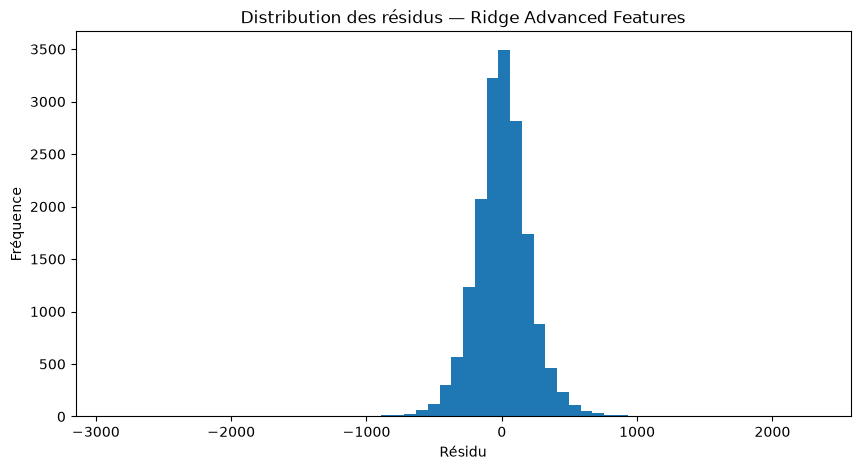

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    residuals_val,
    bins=60
)

plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus — Ridge Advanced Features")

plt.show()

In [ ]:
print(
    "Moyenne des résidus :",
    residuals_val.mean()
)

print(
    "Écart-type des résidus :",
    residuals_val.std()
)

print(
    "Résidu médian :",
    residuals_val.median()
)

Moyenne des résidus : 2.700936617035254
Écart-type des résidus : 210.8823270084664
Résidu médian : 2.8892827864583523


#### 21.5.3 Autocorrélation des résidus

In [ ]:
important_lags = [
    1,      # 30 min
    2,      # 1 h
    6,      # 3 h
    12,     # 6 h
    24,     # 12 h
    48,     # 1 jour
    96,     # 2 jours
    336     # 1 semaine
]

for lag in important_lags:

    autocorr = residuals_val.autocorr(
        lag=lag
    )

    print(
        f"Lag {lag} :",
        autocorr
    )

Lag 1 : 0.09656490768588996
Lag 2 : 0.034811895782874885
Lag 6 : 0.016202227020636083
Lag 12 : 0.009844991218114305
Lag 24 : 0.012607436107709775
Lag 48 : 0.0070030703189249265
Lag 96 : 0.08424837991394266
Lag 336 : 0.1345231043241933


<Figure size 1200x600 with 0 Axes>

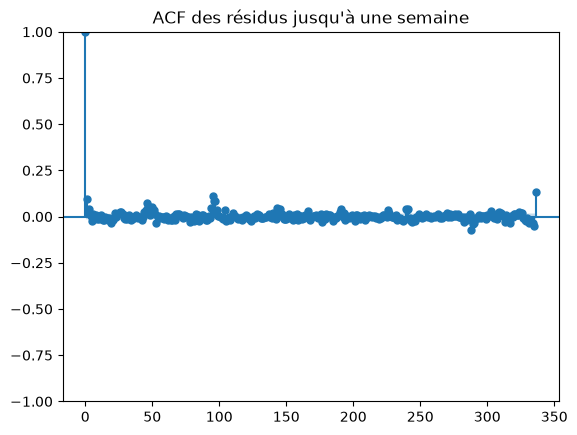

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 6))

plot_acf(
    residuals_val.dropna(),
    lags=336
)

plt.title(
    "ACF des résidus jusqu'à une semaine"
)

plt.show()

#### 21.5.4 Erreur selon l'heure

In [ ]:
residual_analysis = pd.DataFrame({
    "residual": residuals_val,
    "abs_error": np.abs(
        residuals_val
    )
})

residual_analysis["hour"] = (
    residual_analysis.index.hour
)

residual_analysis["dayofweek"] = (
    residual_analysis.index.dayofweek
)

residual_analysis["month"] = (
    residual_analysis.index.month
)

In [ ]:
error_by_hour = (
    residual_analysis
    .groupby("hour")["abs_error"]
    .mean()
)

error_by_hour

hour
0     118.804923
1     105.734375
2     120.168349
3     134.707961
4     172.976363
5     199.337956
6     172.839439
7     162.921295
8     155.926263
9     147.570232
10    156.979273
11    191.716311
12    176.162666
13    163.527376
14    141.749209
15    148.616751
16    165.700646
17    180.192314
18    175.807959
19    153.355555
20    134.599048
21    139.986787
22    120.958121
23    127.245009
Name: abs_error, dtype: float64

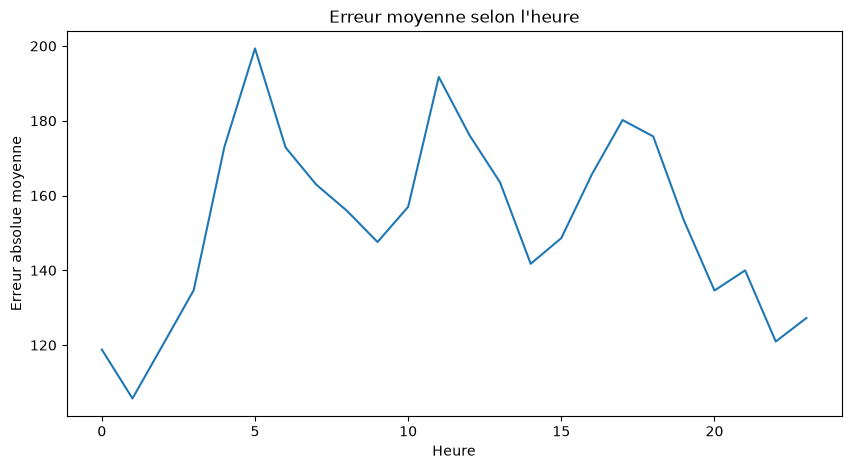

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    error_by_hour.index,
    error_by_hour.values
)

plt.xlabel("Heure")
plt.ylabel("Erreur absolue moyenne")
plt.title("Erreur moyenne selon l'heure")

plt.show()

#### 21.5.5 Erreur selon le jour de la semaine

In [ ]:
error_by_day = (
    residual_analysis
    .groupby("dayofweek")["abs_error"]
    .mean()
)

error_by_day

dayofweek
0    182.244706
1    147.111533
2    136.977929
3    144.826084
4    135.612599
5    155.606445
6    167.637335
Name: abs_error, dtype: float64

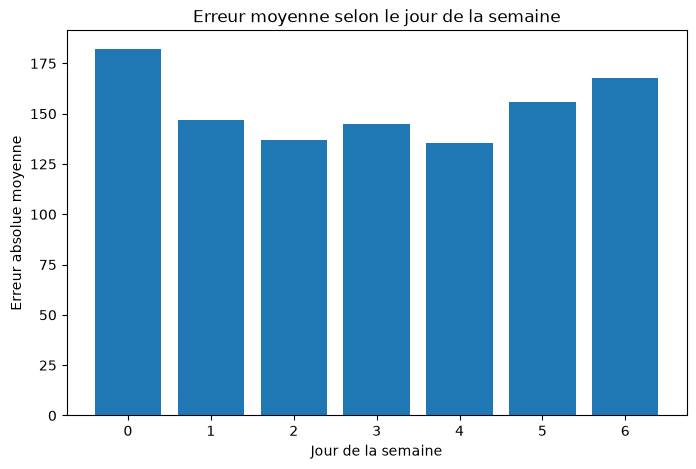

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    error_by_day.index,
    error_by_day.values
)

plt.xlabel("Jour de la semaine")
plt.ylabel("Erreur absolue moyenne")
plt.title("Erreur moyenne selon le jour de la semaine")

plt.show()

#### 21.5.6 Erreur selon le mois

In [ ]:
error_by_month = (
    residual_analysis
    .groupby("month")["abs_error"]
    .mean()
)

error_by_month

month
1     171.270294
2     156.086775
3     180.849401
4     174.106906
5     148.344914
6     140.200163
7     120.241232
8     112.430254
9     144.986175
10    175.861343
11    160.701221
12    149.311566
Name: abs_error, dtype: float64

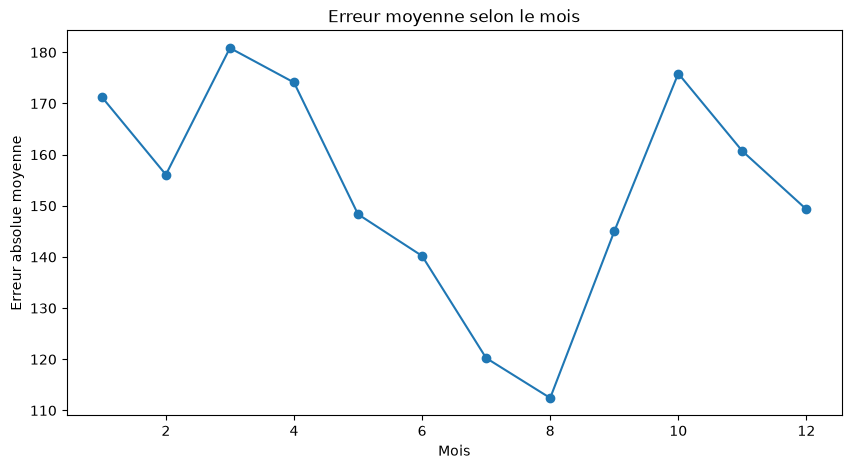

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    error_by_month.index,
    error_by_month.values,
    marker="o"
)

plt.xlabel("Mois")
plt.ylabel("Erreur absolue moyenne")
plt.title("Erreur moyenne selon le mois")

plt.show()

In [ ]:
residual_analysis_path = os.path.join(
    models_folder,
    "residual_analysis.joblib"
)

joblib.dump(
    {
        "residuals": residuals_val,
        "error_by_hour": error_by_hour,
        "error_by_day": error_by_day,
        "error_by_month": error_by_month
    },
    residual_analysis_path
)

print(
    "Analyse des résidus sauvegardée"
)

Analyse des résidus sauvegardée


#### Conclusion de l'analyse des résidus

Les résidus sont globalement bien centrés autour de zéro, ce qui indique l'absence d'un biais global important.

Cependant, une structure temporelle reste présente.

L'autocorrélation est notamment plus élevée au lag hebdomadaire :

$$
Corr(e_t,e_{t-336}) \approx 0.135
$$

ainsi qu'aux lags 1 et 96.

Cela indique que le modèle ne capture pas parfaitement certaines dépendances temporelles.

L'erreur varie également fortement selon le calendrier. Les périodes les plus difficiles apparaissent notamment :

- autour de 5 h,
- autour de 11 h,
- en fin d'après-midi vers 17–18 h,
- le lundi et le dimanche,
- au printemps et en automne.

Ces résultats suggèrent que l'effet des lags n'est peut-être pas constant selon l'heure, le jour ou la saison.

La prochaine étape consiste donc à tester des interactions entre les variables temporelles et certains lags importants.

#### 21.5.7 Biais des résidus selon les périodes temporelles

In [ ]:
bias_by_hour = (
    residual_analysis
    .groupby("hour")["residual"]
    .mean()
)

bias_by_day = (
    residual_analysis
    .groupby("dayofweek")["residual"]
    .mean()
)

bias_by_month = (
    residual_analysis
    .groupby("month")["residual"]
    .mean()
)

In [ ]:
print("Biais selon l'heure :")
print(bias_by_hour)

print("\nBiais selon le jour :")
print(bias_by_day)

print("\nBiais selon le mois :")
print(bias_by_month)

Biais selon l'heure :
hour
0      8.045741
1     12.319667
2     11.456272
3     11.374734
4      1.877576
5    -12.055983
6    -16.828311
7     -7.247239
8      7.477700
9     16.227201
10    20.334444
11     3.486201
12    -2.471529
13   -10.767356
14    -4.434729
15     2.800087
16    18.621641
17    23.222786
18     3.481587
19     0.284660
20     1.200050
21    -8.330428
22   -12.609494
23    -2.642800
Name: residual, dtype: float64

Biais selon le jour :
dayofweek
0     7.364683
1   -11.277870
2     2.288049
3     7.019153
4    15.172602
5     1.301112
6    -2.953233
Name: residual, dtype: float64

Biais selon le mois :
month
1     10.991613
2      9.376479
3     -9.750617
4     -8.702989
5      3.052844
6     26.050022
7      3.692284
8      1.134869
9     -1.446714
10     2.768607
11     2.739954
12    -6.596302
Name: residual, dtype: float64


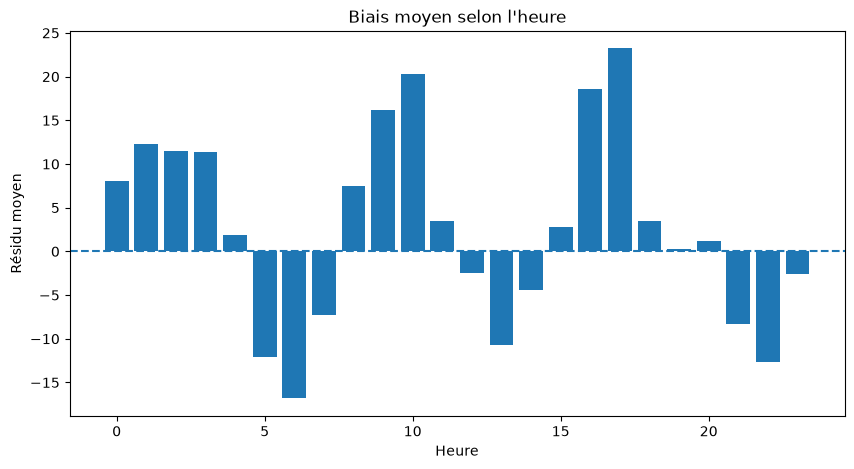

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    bias_by_hour.index,
    bias_by_hour.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Heure")
plt.ylabel("Résidu moyen")
plt.title("Biais moyen selon l'heure")

plt.show()

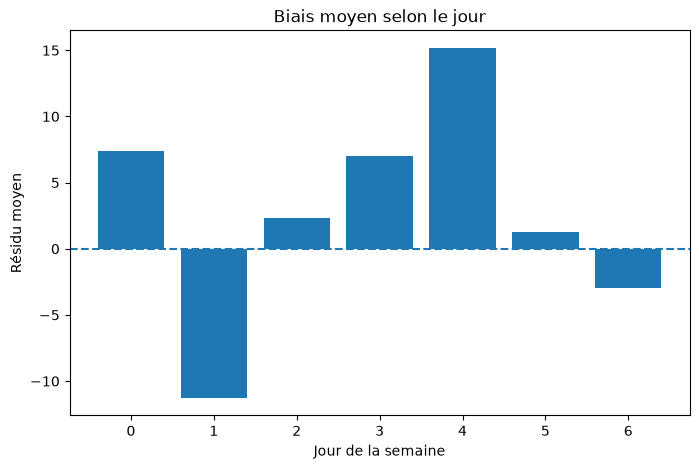

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    bias_by_day.index,
    bias_by_day.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Jour de la semaine")
plt.ylabel("Résidu moyen")
plt.title("Biais moyen selon le jour")

plt.show()

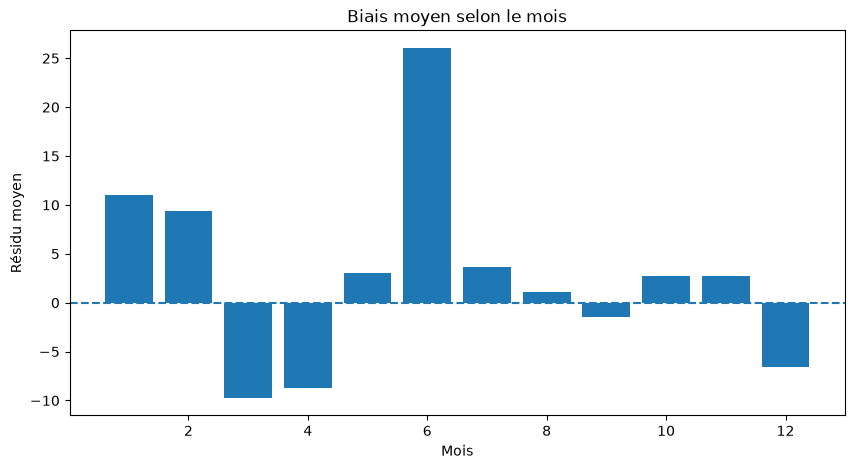

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    bias_by_month.index,
    bias_by_month.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Mois")
plt.ylabel("Résidu moyen")
plt.title("Biais moyen selon le mois")

plt.show()

#### 21.5.8 Enrichissement des variables calendaires à partir des résidus

L'analyse des résidus montre que le biais du modèle dépend encore de l'heure, du jour de la semaine et du mois.

Par exemple, le modèle sous-estime davantage la consommation à certaines heures, notamment autour de 9–10 h et 16–17 h, tandis qu'il la surestime davantage autour de 5–7 h.

Les variables cycliques utilisées jusqu'ici :

$$
\sin\left(\frac{2\pi h}{24}\right)
$$

et

$$
\cos\left(\frac{2\pi h}{24}\right)
$$

représentent une variation périodique relativement lisse.

Cependant, les résidus montrent que l'effet de l'heure n'est pas parfaitement sinusoïdal.

On ajoute donc une représentation plus flexible du calendrier afin de permettre à Ridge d'apprendre des effets spécifiques à certaines heures, certains jours et certains mois.

In [ ]:
calendar_dummies = pd.DataFrame(
    index=X_hd_advanced.index
)

calendar_dummies["hour"] = (
    calendar_dummies.index.hour
)

calendar_dummies["dayofweek"] = (
    calendar_dummies.index.dayofweek
)

calendar_dummies["month"] = (
    calendar_dummies.index.month
)

In [ ]:
calendar_dummies = pd.get_dummies(
    calendar_dummies,
    columns=[
        "hour",
        "dayofweek",
        "month"
    ],
    drop_first=True,
    dtype=float
)

calendar_dummies.shape

(236254, 40)

In [ ]:
X_calendar_adv = pd.concat(
    [
        X_hd_advanced,
        calendar_dummies
    ],
    axis=1
)

calendar_dummies.shape

(236254, 40)

In [ ]:
X_train_calendar = X_calendar_adv.loc[
    X_train_adv.index
]

X_val_calendar = X_calendar_adv.loc[
    X_val_adv.index
]

#### 21.5.9 Ridge avec effets calendaires flexibles

In [ ]:
ridge_calendar = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(
        alpha=0.3994880193954167
    ))
])

In [ ]:
ridge_calendar_path = os.path.join(
    models_folder,
    "ridge_calendar_enriched.joblib"
)

if os.path.exists(ridge_calendar_path):

    ridge_calendar = joblib.load(
        ridge_calendar_path
    )

    print(
        "Ridge calendrier enrichi chargé"
    )

else:

    ridge_calendar.fit(
        X_train_calendar,
        y_train_adv
    )

    joblib.dump(
        ridge_calendar,
        ridge_calendar_path
    )

    print(
        "Ridge calendrier enrichi entraîné et sauvegardé"
    )

Ridge calendrier enrichi chargé


In [ ]:
pred_ridge_calendar = ridge_calendar.predict(
    X_val_calendar
)

rmse_ridge_calendar = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_ridge_calendar
    )
)

mae_ridge_calendar = mean_absolute_error(
    y_val_adv,
    pred_ridge_calendar
)

print(
    "Ridge Calendar RMSE :",
    rmse_ridge_calendar
)

print(
    "Ridge Calendar MAE :",
    mae_ridge_calendar
)

Ridge Calendar RMSE : 210.16897519814012
Ridge Calendar MAE : 152.51356049150564


#### Conclusion sur les effets calendaires flexibles

L'ajout de variables indicatrices pour l'heure, le jour de la semaine et le mois améliore les performances du modèle.

Le RMSE passe de :

$$
210.89
$$

à :

$$
210.17
$$

et le MAE passe de :

$$
152.82
$$

à :

$$
152.51
$$

Cette amélioration confirme que les effets calendaires ne sont pas entièrement décrits par les seules variables cycliques sinusoïdales.

L'analyse des résidus avait montré des biais spécifiques à certaines heures, certains jours et certains mois.

L'ajout d'effets calendaires plus flexibles permet à Ridge de mieux corriger ces structures résiduelles.

Cette amélioration est donc directement issue du diagnostic théorique des résidus.

#### 21.5.10 Interaction du lag hebdomadaire avec le calendrier

L'analyse des résidus montre qu'une dépendance hebdomadaire subsiste :

$$
Corr(e_t,e_{t-336}) \approx 0.135
$$

Cela suggère que la relation entre la consommation actuelle et celle observée une semaine plus tôt n'est peut-être pas constante dans le temps.

On teste donc des interactions entre `lag_336` et les variables calendaires afin de permettre à Ridge d'apprendre un effet hebdomadaire différent selon l'heure ou le jour de la semaine.

In [ ]:
X_week_interactions = X_calendar_adv.copy()

X_week_interactions["lag336_hour_sin"] = (
    X_week_interactions["lag_336"]
    * X_week_interactions["hour_sin"]
)

X_week_interactions["lag336_hour_cos"] = (
    X_week_interactions["lag_336"]
    * X_week_interactions["hour_cos"]
)

X_week_interactions["lag336_dow_sin"] = (
    X_week_interactions["lag_336"]
    * X_week_interactions["dow_sin"]
)

X_week_interactions["lag336_dow_cos"] = (
    X_week_interactions["lag_336"]
    * X_week_interactions["dow_cos"]
)

In [ ]:
X_train_week = X_week_interactions.loc[
    X_train_adv.index
]

X_val_week = X_week_interactions.loc[
    X_val_adv.index
]

#### 21.5.11 Ridge avec interaction hebdomadaire

In [ ]:
ridge_week_interactions = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(
        alpha=0.3994880193954167
    ))
])

In [ ]:
ridge_week_path = os.path.join(
    models_folder,
    "ridge_week_interactions.joblib"
)

if os.path.exists(ridge_week_path):

    ridge_week_interactions = joblib.load(
        ridge_week_path
    )

    print(
        "Ridge interactions hebdomadaires chargé"
    )

else:

    ridge_week_interactions.fit(
        X_train_week,
        y_train_adv
    )

    joblib.dump(
        ridge_week_interactions,
        ridge_week_path
    )

    print(
        "Ridge interactions hebdomadaires entraîné et sauvegardé"
    )

Ridge interactions hebdomadaires chargé


In [ ]:
pred_ridge_week = ridge_week_interactions.predict(
    X_val_week
)

rmse_ridge_week = np.sqrt(
    mean_squared_error(
        y_val_adv,
        pred_ridge_week
    )
)

mae_ridge_week = mean_absolute_error(
    y_val_adv,
    pred_ridge_week
)

print(
    "Ridge Week Interaction RMSE :",
    rmse_ridge_week
)

print(
    "Ridge Week Interaction MAE :",
    mae_ridge_week
)

Ridge Week Interaction RMSE : 210.14448494180678
Ridge Week Interaction MAE : 152.5431677956116


#### Conclusion sur l'interaction hebdomadaire

L'analyse des résidus avait révélé une autocorrélation relativement importante au lag hebdomadaire :

$$
Corr(e_t,e_{t-336}) \approx 0.135
$$

Des interactions entre `lag_336` et les variables calendaires ont donc été ajoutées.

Le RMSE passe de :

$$
210.169
$$

à :

$$
210.144
$$

ce qui constitue une légère amélioration.

Le MAE augmente légèrement :

$$
152.514 \rightarrow 152.543
$$

L'amélioration est donc faible, mais elle confirme que l'effet de la consommation observée une semaine auparavant dépend légèrement du contexte temporel.

Cette expérience illustre directement la démarche :

$$
\text{diagnostic des résidus}
\rightarrow
\text{nouvelle hypothèse}
\rightarrow
\text{feature engineering ciblé}
\rightarrow
\text{amélioration du modèle}
$$

### 21.6 Feature engineering guidé par la théorie

Les expériences précédentes montrent que le feature engineering peut être directement guidé par l'analyse statistique du modèle.

Plusieurs types de variables ont été introduits au cours du projet.

#### Différences temporelles

Les variables telles que :

- `diff_1`,
- `diff_day`,
- `diff_week`

mesurent directement l'évolution de la consommation par rapport à une période précédente.

Par exemple :

$$
diff\_day_t
=
lag_{1,t}
-
lag_{48,t}
$$

Ces variables permettent au modèle de représenter plus directement les changements journaliers ou hebdomadaires.

#### Écarts aux moyennes récentes

Les variables :

- `dev_mean_3h`,
- `dev_mean_day`,
- `dev_mean_week`

mesurent l'écart entre la consommation récente et son niveau moyen local.

Par exemple :

$$
dev\_mean\_day
=
lag_1
-
rolling\_mean_{48}
$$

Elles permettent de détecter si la consommation est momentanément supérieure ou inférieure à son comportement récent.

#### Effets calendaires flexibles

Les premières variables calendaires utilisaient uniquement des représentations cycliques :

$$
\sin\left(\frac{2\pi h}{24}\right)
$$

et

$$
\cos\left(\frac{2\pi h}{24}\right)
$$

L'analyse des résidus a cependant montré que certaines heures présentaient des biais spécifiques.

Des variables indicatrices pour l'heure, le jour de la semaine et le mois ont donc été ajoutées.

Cette représentation plus flexible améliore le RMSE de :

$$
210.89
$$

à :

$$
210.17
$$

#### Interactions temporelles

L'autocorrélation résiduelle au lag hebdomadaire était encore relativement importante :

$$
Corr(e_t,e_{t-336}) \approx 0.135
$$

Des interactions entre `lag_336` et les variables calendaires ont donc été ajoutées.

Le RMSE diminue encore légèrement jusqu'à :

$$
210.14
$$

Ces expériences montrent que le feature engineering est plus efficace lorsqu'il est guidé par une structure statistique réellement observée dans les données.

#### Conclusion

Le feature engineering ne consiste pas uniquement à créer un grand nombre de variables.

Une approche plus rigoureuse consiste à :

$$
\text{diagnostic statistique}
\rightarrow
\text{hypothèse}
\rightarrow
\text{nouvelle feature}
\rightarrow
\text{validation}
$$

Dans ce projet, l'analyse des résidus a permis d'identifier des structures calendaires et hebdomadaires encore mal modélisées, puis de construire des variables ciblées permettant d'améliorer les performances.

### 21.7 Expériences guidées par la théorie

Plusieurs expériences ont été réalisées à partir des résultats théoriques du Bloc 1.

L'objectif n'était pas de tester arbitrairement de nouveaux modèles, mais de partir d'un diagnostic statistique puis de vérifier expérimentalement ses conséquences.

In [ ]:
theory_experiments = pd.DataFrame({
    "Expérience": [
        "Ridge Advanced Features",
        "Réduction au rang numérique",
        "Sélection par stabilité",
        "Lasso → Ridge",
        "Calendrier enrichi",
        "Interaction hebdomadaire"
    ],

    "Features": [
        372,
        357,
        298,
        244,
        X_train_calendar.shape[1],
        X_train_week.shape[1]
    ],

    "RMSE": [
        210.893604890517,
        210.89360489048676,
        211.04851323625903,
        212.03683028298272,
        210.16897519814012,
        210.14448494180678
    ],

    "MAE": [
        152.81600755863204,
        152.81600755860256,
        152.95524507355003,
        153.38230233680625,
        152.51356049150564,
        152.5431677956116
    ]
})

theory_experiments.sort_values("RMSE")

,Expérience,Features,RMSE,MAE
5,Interaction hebdomadaire,416,210.144485,152.543168
4,Calendrier enrichi,412,210.168975,152.513560
1,Réduction au rang numérique,357,210.893605,152.816008
0,Ridge Advanced Features,372,210.893605,152.816008
2,Sélection par stabilité,298,211.048513,152.955245
3,Lasso → Ridge,244,212.036830,153.382302


In [ ]:
theory_experiments_path = os.path.join(
    models_folder,
    "theory_guided_experiments.joblib"
)

joblib.dump(
    theory_experiments,
    theory_experiments_path
)

print(
    "Résultats des expériences théoriques sauvegardés"
)

Résultats des expériences théoriques sauvegardés


#### Analyse des expériences

Les différentes expériences apportent plusieurs enseignements.

**1. Conditionnement**

La matrice possède 372 variables mais seulement 357 directions numériquement indépendantes.

La suppression des directions redondantes ne modifie pratiquement pas les performances.

Cela montre que Ridge gère déjà efficacement la multicolinéarité.

**2. Stabilité**

La sélection basée sur la stabilité permet de réduire le nombre de variables de 372 à 298 tout en conservant des performances très proches.

Ce modèle constitue un bon compromis entre précision et complexité.

**3. Sparsité**

Lasso permet de réduire le modèle à 244 variables.

Les performances diminuent légèrement, mais le temps d'entraînement est fortement réduit.

La sélection Lasso est également relativement stable entre les folds, avec un indice de Jaccard moyen d'environ :

$$
0.896
$$

Le problème n'est donc pas fortement sparse, mais une partie des variables peut être supprimée sans forte perte de performance.

**4. PCA**

La PCA montre que les directions de faible variance contiennent une information prédictive importante.

Même avec :

$$
99.99\%
$$

de variance expliquée, le modèle PCA reste moins performant que Ridge sur les variables originales.

**5. Résidus**

L'analyse des résidus a été la source d'amélioration la plus intéressante.

Elle a révélé :

- une structure selon l'heure,
- une structure selon le jour,
- une structure saisonnière,
- une autocorrélation hebdomadaire résiduelle.

Ces diagnostics ont conduit à l'ajout de variables calendaires plus flexibles et d'interactions hebdomadaires.

#### Conclusion

Les expériences montrent que toutes les observations théoriques ne conduisent pas nécessairement à une amélioration du RMSE.

Certaines permettent surtout de mieux comprendre le modèle, comme l'étude du conditionnement ou de la PCA.

En revanche, l'analyse des résidus a directement permis d'identifier des structures encore présentes dans les erreurs et de construire de nouvelles variables améliorant les performances.

### 21.8 Résultat final après améliorations guidées par la théorie

Avant l'analyse théorique approfondie, le meilleur modèle était Ridge avec feature engineering avancé :

$$
RMSE \approx 210.89
$$

$$
MAE \approx 152.82
$$

L'analyse des résidus a ensuite montré que certaines structures calendaires n'étaient pas complètement capturées.

L'ajout de variables calendaires flexibles permet d'obtenir :

$$
RMSE \approx 210.17
$$

$$
MAE \approx 152.51
$$

Enfin, l'ajout d'interactions entre le lag hebdomadaire et le calendrier permet d'obtenir le meilleur RMSE :

$$
\boxed{RMSE \approx 210.14}
$$

avec :

$$
MAE \approx 152.54
$$

#### Modèles retenus

Deux modèles peuvent finalement être retenus selon l'objectif.

**Modèle avec meilleure performance prédictive**

Ridge avec :

- features haute dimension,
- feature engineering avancé,
- calendrier enrichi,
- interactions hebdomadaires.

Performance :

$$
\boxed{RMSE \approx 210.14}
$$

Ce modèle est retenu lorsque la priorité est la précision maximale.

**Modèle parcimonieux**

Ridge entraîné après une sélection de variables par Lasso :

- 244 variables au lieu de 372,
- environ 34 % de variables en moins,
- temps d'entraînement réduit d'environ 55 %,
- perte de performance limitée.

Performance :

$$
RMSE \approx 212.04
$$

$$
MAE \approx 153.38
$$

Ce modèle constitue un compromis intéressant lorsque la priorité est de réduire la complexité et le coût de calcul tout en conservant des performances proches du meilleur modèle.

La sélection Lasso permet d'éliminer une partie importante des variables avant d'utiliser Ridge pour bénéficier de coefficients plus stables.

#### Conclusion de la synthèse théorique

Cette partie montre que la théorie permet non seulement d'expliquer les résultats obtenus, mais également de guider les améliorations du modèle.

La multicolinéarité explique l'intérêt de Ridge.

Le compromis biais-variance explique la meilleure stabilité de ses coefficients.

L'analyse de sparsité permet d'identifier des modèles plus parcimonieux.

La PCA montre que les directions de faible variance peuvent contenir une information prédictive importante.

Enfin, l'analyse des résidus permet d'identifier directement des structures encore non modélisées et conduit aux améliorations les plus importantes.

La démarche suivie peut être résumée par :

$$
\boxed{
\text{Théorie}
\rightarrow
\text{Diagnostic}
\rightarrow
\text{Expérience}
\rightarrow
\text{Amélioration}
}
$$

## 22. Conclusion générale du Bloc 1

Ce premier bloc a permis d'étudier en profondeur les principaux outils de statistique en grande dimension et leur application à un problème réel de prévision de consommation électrique.

Plusieurs enseignements importants ressortent de l'ensemble des expériences.

### 1. Le feature engineering est déterminant

Le passage d'un modèle utilisant seulement quelques variables temporelles à une représentation haute dimension a produit l'amélioration la plus importante.

L'OLS simple obtenait environ :

$$
RMSE \approx 958
$$

alors que les modèles haute dimension atteignent environ :

$$
RMSE \approx 211
$$

Cela montre que, dans ce problème, la qualité de la représentation des données a beaucoup plus d'impact que le choix précis de l'algorithme.

### 2. Ridge est particulièrement adapté

Les nombreuses variables de lag, rolling statistics et transformations temporelles sont fortement corrélées.

L'analyse du conditionnement a montré un nombre de condition extrêmement élevé :

$$
\kappa(X) \approx 9.3 \times 10^{16}
$$

ce qui confirme une forte multicolinéarité.

Ridge est particulièrement adapté à cette situation car la pénalisation L2 stabilise les coefficients.

Cette stabilité a également été observée expérimentalement entre plusieurs folds temporels.

### 3. Le problème n'est pas fortement sparse

Lasso élimine une partie des variables, mais conserve encore une majorité des features.

Environ 65 % des coefficients restent non nuls.

La sélection obtenue est relativement stable dans le temps, avec un indice de Jaccard moyen proche de :

$$
0.896
$$

Le problème n'est donc pas fortement sparse, mais Lasso reste utile comme outil de sélection de variables.

### 4. PCA n'est pas adaptée à l'objectif prédictif

La PCA permet de compresser fortement la matrice de features.

Cependant, les expériences montrent que certaines directions de faible variance contiennent une information prédictive importante.

Même avec :

$$
99.99\%
$$

de variance expliquée, les performances restent inférieures à celles de Ridge sur les variables originales.

Cette expérience montre que :

$$
\text{variance expliquée}
\neq
\text{importance prédictive}
$$

### 5. La théorie permet de guider les améliorations

L'analyse des résidus a montré que certaines structures temporelles restaient présentes dans les erreurs.

En particulier, des biais dépendant de l'heure, du jour et du mois ont été détectés, ainsi qu'une autocorrélation hebdomadaire résiduelle.

Ces diagnostics ont conduit à l'ajout :

- de variables calendaires plus flexibles,
- d'interactions entre le lag hebdomadaire et le calendrier.

Ces modifications ont permis d'améliorer encore le modèle.

### 6. Meilleur modèle prédictif

Le meilleur modèle obtenu est Ridge avec :

- features haute dimension,
- feature engineering avancé,
- effets calendaires enrichis,
- interactions hebdomadaires.

Ses performances sur la validation 2025 sont :

$$
\boxed{RMSE \approx 210.14}
$$

et :

$$
\boxed{MAE \approx 152.54}
$$

### 7. Modèle parcimonieux

Une version plus compacte est également retenue.

Lasso est d'abord utilisé pour sélectionner les variables, puis Ridge est entraîné sur les variables conservées.

Ce modèle utilise :

$$
244
$$

variables au lieu de :

$$
372
$$

soit environ 34 % de variables en moins.

Son temps d'entraînement est réduit d'environ 55 %, pour des performances restant proches :

$$
RMSE \approx 212.04
$$

$$
MAE \approx 153.38
$$

Il constitue donc une alternative intéressante lorsque la simplicité et le coût de calcul sont prioritaires.

### Conclusion finale

Le résultat principal de ce Bloc 1 est que la performance ne dépend pas uniquement du choix du modèle.

Elle dépend surtout de la compréhension de la structure des données et de la construction de variables adaptées.

La démarche suivie peut être résumée par :

$$
\boxed{
\text{Théorie}
\rightarrow
\text{Diagnostic}
\rightarrow
\text{Feature Engineering}
\rightarrow
\text{Validation}
}
$$

Cette approche permet d'obtenir un modèle à la fois performant, interprétable et statistiquement justifié.

In [ ]:
data_folder = os.path.join(
    os.getcwd(),
    "data_processed"
)

os.makedirs(
    data_folder,
    exist_ok=True
)

In [ ]:
df_model_path = os.path.join(
    data_folder,
    "df_model_block1.joblib"
)

joblib.dump(
    df_model,
    df_model_path
)

print("df_model sauvegardé")

df_model sauvegardé


In [ ]:
X_final_path = os.path.join(
    data_folder,
    "X_block1_final.joblib"
)

joblib.dump(
    X_week_interactions,
    X_final_path
)

print("X final sauvegardé")

X final sauvegardé


In [ ]:
y_final_path = os.path.join(
    data_folder,
    "y_block1_final.joblib"
)

joblib.dump(
    y_hd_advanced,
    y_final_path
)

print("y final sauvegardé")

y final sauvegardé


In [ ]:
X_block1 = joblib.load(
    "data_processed/X_block1_final.joblib"
)

y_block1 = joblib.load(
    "data_processed/y_block1_final.joblib"
)

In [ ]:
feature_lists = {
    "features_hd": features_hd,
    "features_hd_advanced": features_hd_advanced,
    "features_stable": features_stable,
    "lasso_selected_features": lasso_selected_features
}

joblib.dump(
    feature_lists,
    os.path.join(
        data_folder,
        "feature_lists.joblib"
    )
)

['c:\\Users\\thiba\\OneDrive\\Bureau\\Programme python\\Projet energie\\data_processed\\feature_lists.joblib']

In [ ]:
feature_lists = joblib.load(
    "data_processed/feature_lists.joblib"
)

features_hd = feature_lists[
    "features_hd"
]

features_hd_advanced = feature_lists[
    "features_hd_advanced"
]

features_stable = feature_lists[
    "features_stable"
]

lasso_selected_features = feature_lists[
    "lasso_selected_features"
]

In [ ]:
split_config = {
    "train_end": "2025-01-01",
    "validation_start": "2025-01-01",
    "validation_end": "2026-01-01",
    "test_start": "2026-01-01"
}

joblib.dump(
    split_config,
    os.path.join(
        data_folder,
        "split_config.joblib"
    )
)

['c:\\Users\\thiba\\OneDrive\\Bureau\\Programme python\\Projet energie\\data_processed\\split_config.joblib']